
# Shiv Nadar University Chennai
## CS3807 – Deep Learning Laboratory
# Experiment 5
### Comprehensive Study of CNN Training, Regularization, Optimization, Hyperparameter Tuning, Transfer Learning and Cross-Validation

| Field | Details |
|---|---|
| **Degree & Branch** | B.Tech Artificial Intelligence & Data Science |
| **Semester** | V |
| **Subject Code & Name** | CS3807 – Deep Learning Laboratory |
| **AY** | 2026–27 |
| **Name** | Miruthula JMM |
| **Reg. No.** | 24011101039 |
| **Class** | AI DS - A (Batch 2) |

---

**Architecture:** MobileNetV2 (ImageNet-pretrained)
**Dataset:** Oxford-IIIT Pet Dataset (37 breeds, RGB, resized to 224×224×3)

This notebook follows the manual section-by-section: weight initialization → regularization/overfitting →
Batch Normalization → optimizers → hyperparameter tuning → transfer learning & fine-tuning →
5-fold cross-validation → final evaluation. All required plots are generated inline **and** saved as
**600 DPI vector EPS** files (bold axis labels, bold legend, uniform font) to `./figures/`.



## 0. Environment Setup and Publication-Quality Plot Style

All figures in this notebook are exported at **600 DPI** in **EPS** vector format, with **bold** axis
labels and **bold** legend text, using a single consistent font family/size to match the printed
laboratory manual (Computer Modern / serif style, 12pt base).

**Compute budget, read before running:** MobileNetV2 transfer learning needs realistic epoch counts to
actually converge — 2-3 epochs will not produce meaningful accuracy numbers, regardless of how fast the
notebook runs. Rather than cutting epochs to fit a free Kaggle/Colab session, this notebook cuts the
**number of configurations trained** in the two most expensive stages (Section 11's 5-fold CV and
Section 16's additional exercise) and keeps **full, real epoch counts** on every configuration that
does run, so the results you get are actually trustworthy.

- `RUN_MODE = "kaggle"` (default): runs 3 of the 4 candidate CV configurations and both of the 2 additional
  configurations, each with a full epoch budget (see the `EPOCHS` dict below). This is the mode intended
  for a single Kaggle GPU session (P100/T4).
- `RUN_MODE = "full"`: runs all 4 CV configurations and both additional configurations, same epoch
  counts. This roughly doubles total training time and is intended for either a stronger GPU, a longer
  session, or running across multiple resumed sessions (results are checkpointed to `./results/*.json`
  after each configuration, so you can restart the kernel and pick up where you left off).

Every other section (weight initialization, regularization, optimizers, hyperparameter sweeps) already
only trains 3-4 lightweight, frozen-base configurations each, so those keep full epochs in both modes.

**Kaggle optimization:** the notebook keeps **10 epochs for every major experiment** and **15 final epochs**, while reducing memory pressure with GPU memory growth, mixed precision, disk-backed TFDS caching, explicit cleanup, and a small number of redundant CV candidates. All major experiments use their complete configured epoch budget for controlled comparison.


In [15]:

import os, time, json, random, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import KFold
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_fscore_support, accuracy_score)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Kaggle stability: let TensorFlow grow GPU memory instead of reserving
# the entire device up front. Mixed precision reduces activation memory
# and is well supported on Kaggle T4/P100 GPUs.
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

if gpus:
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy("mixed_float16")
        print("Mixed precision enabled:", mixed_precision.global_policy())
    except Exception as e:
        print("Mixed precision unavailable:", e)


FIG_DIR = "./figures"
RESULTS_DIR = "./results"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---------------------------------------------------------------
# RUN_MODE controls epoch budget per stage. Redesigned around Kaggle's real
# constraints (~13GB RAM, single P100/T4 GPU, 30 GPU-hrs/week quota) by
# reducing the NUMBER OF CONFIGURATIONS trained rather than epochs per
# configuration -- a config trained for too few epochs never actually
# converges, so its "result" is meaningless regardless of how fast it ran.
#
#   "kaggle" -> fewer candidate configs (see Sections 11 & 16), but FULL,
#               real epoch counts on each one so results are trustworthy.
#               This is the default and the recommended mode for a
#               single Kaggle GPU session.
#   "full"   -> the full 3-4 candidate sweep the manual describes, still with
#               full epochs. Only use this with a fast GPU and generous quota,
#               or across multiple resumed sessions (see save_json checkpoints).
# ---------------------------------------------------------------
RUN_MODE = "kaggle"

EPOCHS = {
    "init":  10,     # cheap: frozen base, classifier head only -- full epochs affordable
    "reg":   10,
    "opt":   10,
    "hp":    10,
    "fe":    10,
    "ft":    10,
    "cv":    10,     # was 2-5; now a real epoch count so fold accuracy is meaningful
    "final": 15,
}
print("RUN_MODE:", RUN_MODE, "| epoch budget:", EPOCHS)

# Number of CV candidate configurations -- this is the lever we pull instead
# of cutting epochs. "kaggle" mode trains 2 configs x 5 folds = 10 model
# fits in Section 11 instead of 4 configs x 5 folds = 20; "full" mode restores
# all 4. Same idea applied to the Additional Exercise in Section 16.
N_CV_CONFIGS = 3 if RUN_MODE == "kaggle" else 4
N_ADDITIONAL_CONFIGS = 2 if RUN_MODE == "kaggle" else 2
print(f"N_CV_CONFIGS = {N_CV_CONFIGS} | N_ADDITIONAL_CONFIGS = {N_ADDITIONAL_CONFIGS}")

# ---------------------------------------------------------------
# Two-resolution strategy to control peak RAM/VRAM:
#   IMG_SIZE_SWEEP -> used for every exploratory stage (Sections 5-11):
#                     initialization, regularization, optimizers, hyperparameter
#                     tuning, transfer learning/fine-tuning demo, and K-Fold CV.
#                     Lower resolution here cuts memory and compute substantially
#                     with negligible impact on *which* configuration wins.
#   IMG_SIZE_FINAL  -> used ONLY for the final retrained model in Section 12,
#                      matching the manual's required 224x224x3 input size.
# This is standard practice: cheap proxy sweeps at reduced resolution, full
# resolution for the model that is actually reported/evaluated.
# ---------------------------------------------------------------
IMG_SIZE_SWEEP = 160 if RUN_MODE == "kaggle" else 192
IMG_SIZE_FINAL = 224
print(f"IMG_SIZE_SWEEP = {IMG_SIZE_SWEEP} | IMG_SIZE_FINAL = {IMG_SIZE_FINAL}")

def free_memory(*objs):
    # Explicitly delete objects, clear the Keras session, and force garbage
    # collection. Call this after every model.fit() loop iteration to prevent
    # the RAM/VRAM creep that crashes Colab/Kaggle across many sequential runs.
    for o in objs:
        try:
            del o
        except Exception:
            pass
    keras.backend.clear_session()
    gc.collect()

def print_memory(tag=""):
    # Best-effort RAM/GPU usage printout so you can see the actual numbers
    # in Kaggle/Colab instead of guessing where the ceiling is.
    try:
        import psutil
        proc = psutil.Process(os.getpid())
        ram_gb = proc.memory_info().rss / 1e9
        print(f"[MEM{' - ' + tag if tag else ''}] Process RAM: {ram_gb:.2f} GB")
    except Exception as e:
        print(f"[MEM] psutil unavailable ({e})")
    try:
        gpu_info = tf.config.experimental.get_memory_info("GPU:0")
        print(f"[MEM{' - ' + tag if tag else ''}] GPU current: "
              f"{gpu_info['current'] / 1e9:.2f} GB | peak: {gpu_info['peak'] / 1e9:.2f} GB")
    except Exception:
        pass  # no GPU, or TF version without this API

def save_json(obj, name):
    # Persist intermediate results to disk after each stage so a crash
    # does not lose earlier work; also allows resuming/inspecting later.
    path = os.path.join(RESULTS_DIR, f"{name}.json")
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)
    print(f"Saved results: {path}")

# ---------------------------------------------------------------
# Manual-matching plot style: bold axes/legend, uniform serif font,
# 600 DPI EPS export for every figure.
# ---------------------------------------------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif", "Times New Roman"],
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 1.2,
    "lines.linewidth": 2.0,
    "figure.dpi": 150,          # on-screen preview
    "savefig.dpi": 600,         # export DPI
    "savefig.format": "eps",
    "savefig.bbox": "tight",
})

def style_axes(ax):
    '''Apply bold tick labels + bold legend text to a matplotlib Axes.'''
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    leg = ax.get_legend()
    if leg is not None:
        for text in leg.get_texts():
            text.set_fontweight("bold")
        leg.get_frame().set_linewidth(1.0)

def save_fig(fig, name):
    '''Save a figure as 600 DPI EPS (and a PNG preview) into FIG_DIR.'''
    eps_path = os.path.join(FIG_DIR, f"{name}.eps")
    png_path = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(eps_path, format="eps", dpi=600, bbox_inches="tight")
    fig.savefig(png_path, format="png", dpi=200, bbox_inches="tight")
    print(f"Saved: {eps_path}  |  {png_path}")

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

print("Kaggle-safe training helper loaded before all experiment cells.")


Mixed precision enabled: <DTypePolicy "mixed_float16">
RUN_MODE: kaggle | epoch budget: {'init': 10, 'reg': 10, 'opt': 10, 'hp': 10, 'fe': 10, 'ft': 10, 'cv': 10, 'final': 15}
N_CV_CONFIGS = 3 | N_ADDITIONAL_CONFIGS = 2
IMG_SIZE_SWEEP = 160 | IMG_SIZE_FINAL = 224
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Kaggle-safe training helper loaded before all experiment cells.



## 1. Objective

The objective of this experiment is to systematically study the effect of weight initialization,
regularization, optimization algorithms, CNN hyperparameters, transfer learning, fine-tuning and
cross-validation on image classification performance.

The experiment uses a single CNN architecture, **MobileNetV2**, and the **Oxford-IIIT Pet dataset**.
We analyze the effect of individual design choices using training/validation curves and finally select
a suitable configuration using **5-fold cross-validation**.

## 2. Learning Outcomes

After completing this experiment, we are able to:
- explain different weight initialization strategies;
- identify and analyze overfitting using training and validation curves;
- compare SGD, Momentum, RMSProp and Adam;
- explain CNN hyperparameters such as kernel size, stride, padding and pooling;
- understand Batch Normalization and Dropout;
- perform transfer learning and fine-tuning using MobileNetV2;
- tune important training hyperparameters;
- apply 5-fold cross-validation for model selection; and
- justify the final model using accuracy, variability and computational cost.



## 3. Dataset and Experimental Setup

**Dataset: Oxford-IIIT Pet Dataset** — images of cats and dogs belonging to 37 breeds, RGB, of varying
spatial dimensions. All images are resized to **224 × 224 × 3**.

**Experimental considerations**
- Use RGB images resized to 224 × 224.
- Normalize the input images according to the pretrained model requirements (MobileNetV2 `preprocess_input`).
- Maintain separate training, validation and test data.
- The test set must remain untouched during hyperparameter selection.
- MobileNetV2 is used because it is computationally lighter than many large CNN architectures and is
  more suitable for CPU-based laboratory work.

We load the dataset via `tensorflow_datasets` (`oxford_iiit_pet`), which provides a train/test split;
we further split the provided training portion into train/validation.


In [16]:

import tensorflow_datasets as tfds

BATCH_SIZE_DEFAULT = 32
NUM_CLASSES = 37  # 37 breeds

# NOTE on resolution: this notebook uses IMG_SIZE_SWEEP (set in Section 0) for
# every exploratory stage and IMG_SIZE_FINAL=224 only for the final retrained
# model in Section 12, to keep peak memory manageable on free Colab/Kaggle
# instances. See the note in Section 0 for the rationale.

# Load Oxford-IIIT Pet with the breed-classification label
(ds_train_full, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    with_info=True,
    as_supervised=True,   # returns (image, label) with label = breed id (0-36)
)

print(ds_info)

def preprocess(image, label, augment=False, img_size=None):
    img_size = img_size or IMG_SIZE_SWEEP
    image = tf.image.resize(image, (img_size, img_size))
    if augment:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, 0.1)
    image = preprocess_input(tf.cast(image, tf.float32))
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

# Split the training portion (90/10) into train / validation
n_train_full = ds_info.splits["train"].num_examples
val_frac = 0.1
n_val = int(n_train_full * val_frac)

ds_train_full = ds_train_full.shuffle(2048, seed=SEED)
ds_val_raw   = ds_train_full.take(n_val)
ds_train_raw = ds_train_full.skip(n_val)

print(f"Train examples: {n_train_full - n_val} | Val examples: {n_val} | "
      f"Test examples: {ds_info.splits['test'].num_examples}")

def make_pipeline(ds_raw, batch_size=BATCH_SIZE_DEFAULT, augment=False, shuffle=False, img_size=None):
    ds = ds_raw
    if shuffle:
        ds = ds.shuffle(1024, seed=SEED)
    ds = ds.map(lambda x, y: preprocess(x, y, augment=augment, img_size=img_size),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Default train/val/test pipelines at IMG_SIZE_SWEEP resolution, used by
# Sections 5-10. Section 12 builds its own 224x224 pipelines for the final model.
train_ds = make_pipeline(ds_train_raw, augment=True, shuffle=True)
val_ds   = make_pipeline(ds_val_raw, augment=False, shuffle=False)
test_ds  = make_pipeline(ds_test, augment=False, shuffle=False)

print_memory("after building base pipelines")


tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='/root/tensorflow_datasets/oxford_iiit_pet/4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
        'head_bbox': BBoxFeature(shape=(4,), dtype=float32),
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLab

Saved: ./figures/sample_pet_images.eps  |  ./figures/sample_pet_images.png


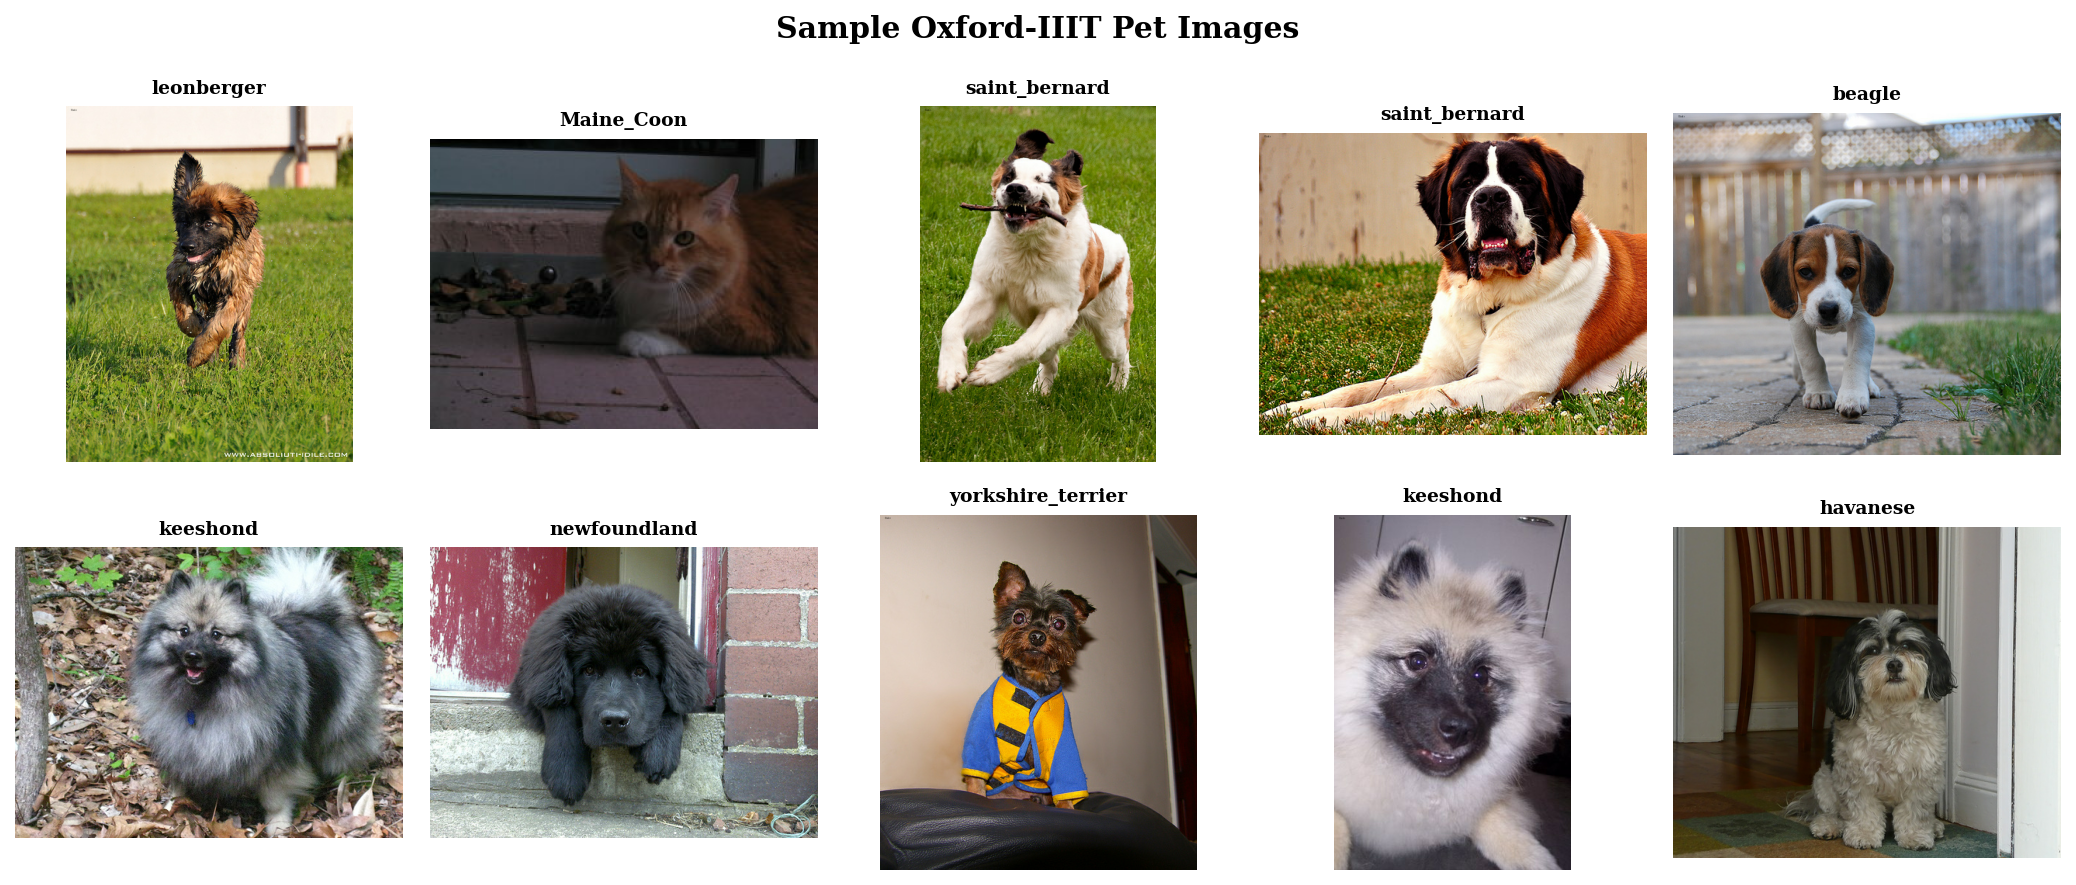

In [17]:

# Display a few sample images (sanity check, not a numbered manual plot).
# NOTE: ds_test here is the RAW tfds.load() output (uint8, [0,255], not yet
# resized/preprocessed) -- imshow can display uint8 images directly without
# any rescaling. (An earlier version of this cell incorrectly applied an
# inverse-normalization formula meant for preprocess_input() output, which
# produced washed-out, noisy-looking images since raw uint8 was never
# normalized in the first place.)
class_names = ds_info.features["label"].names

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for (img, lbl), ax in zip(ds_test.take(10), axes.flat):
    ax.imshow(img.numpy())  # raw uint8 image, displays correctly as-is
    ax.set_title(class_names[lbl.numpy()], fontsize=9, fontweight="bold")
    ax.axis("off")
plt.suptitle("Sample Oxford-IIIT Pet Images", fontweight="bold")
plt.tight_layout()
save_fig(fig, "sample_pet_images")
plt.show()



## 4. MobileNetV2 Architecture

MobileNetV2 is a lightweight CNN architecture designed to reduce computational complexity while
maintaining good image representation. Its important components include:

- depthwise convolution;
- pointwise 1 × 1 convolution;
- inverted residual blocks;
- linear bottlenecks;
- batch normalization; and
- ReLU6 activation.

**Simplified conceptual pipeline:**

`Input (224×224×3) → Conv → Depthwise Conv → Pointwise Conv → Residual Block → Global Avg. Pooling → Dense → Softmax`

*(This is a simplified conceptual representation rather than the complete MobileNetV2 architecture.)*


In [18]:

base_preview = MobileNetV2(input_shape=(IMG_SIZE_SWEEP, IMG_SIZE_SWEEP, 3), include_top=False, weights="imagenet")
print(f"MobileNetV2 base: {base_preview.count_params():,} parameters")
print(f"Number of layers: {len(base_preview.layers)}")
free_memory(base_preview)


MobileNetV2 base: 2,257,984 parameters
Number of layers: 154



## 5. Weight Initialization

Weight initialization determines the initial values of trainable weights before training begins. A
suitable initialization can improve convergence and reduce problems such as vanishing or exploding
activations.

We compare, on the **classification head only** (base MobileNetV2 frozen, ImageNet weights):
- Zero initialization
- Random (Normal) initialization
- Xavier / Glorot initialization
- He initialization

### Plot 1 — Training Loss vs. Epoch (one curve per initialization)
### Plot 2 — Validation Accuracy vs. Epoch (one curve per initialization)


In [19]:

def build_model_with_init(kernel_init, dense_units=128, dropout_rate=0.0,
                           use_bn=False, l2_reg=0.0, img_size=None):
    img_size = img_size or IMG_SIZE_SWEEP
    base = MobileNetV2(input_shape=(img_size, img_size, 3), include_top=False, weights="imagenet")
    base.trainable = False

    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, kernel_initializer=kernel_init, kernel_regularizer=reg)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax",
                            kernel_initializer=kernel_init, dtype="float32")(x)
    model = keras.Model(inputs, outputs)
    return model

INIT_EPOCHS = EPOCHS["init"]

initializers_to_test = {
    "Zero":   keras.initializers.Zeros(),
    "Random": keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=SEED),
    "Xavier": keras.initializers.GlorotUniform(seed=SEED),
    "He":     keras.initializers.HeNormal(seed=SEED),
}

init_histories = {}

for name, init in initializers_to_test.items():
    print(f"\n=== Training with {name} initialization ===")
    tf.random.set_seed(SEED)
    model = build_model_with_init(init)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                   loss="categorical_crossentropy", metrics=["accuracy"])
    hist = model.fit(train_ds, validation_data=val_ds, epochs=INIT_EPOCHS, verbose=1)
    init_histories[name] = hist.history
    free_memory(model)



=== Training with Zero initialization ===
Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 27s 152ms/step - accuracy: 0.0232 - loss: 3.6114 - val_accuracy: 0.0299 - val_loss: 3.6109
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.0269 - loss: 3.6112 - val_accuracy: 0.0217 - val_loss: 3.6109
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.0236 - loss: 3.6113 - val_accuracy: 0.0163 - val_loss: 3.6113
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.0239 - loss: 3.6112 - val_accuracy: 0.0217 - val_loss: 3.6120
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.0202 - loss: 3.6113 - val_accuracy: 0.0245 - val_loss: 3.6114
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.0202 - loss: 3.6111 - val_accuracy: 0.0217 - val_loss: 3.6110
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.0254 - loss: 3.6112 - val_accuracy: 0.0136 - val_loss: 3.6126
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step

Saved: ./figures/plot1_training_loss_initialization.eps  |  ./figures/plot1_training_loss_initialization.png


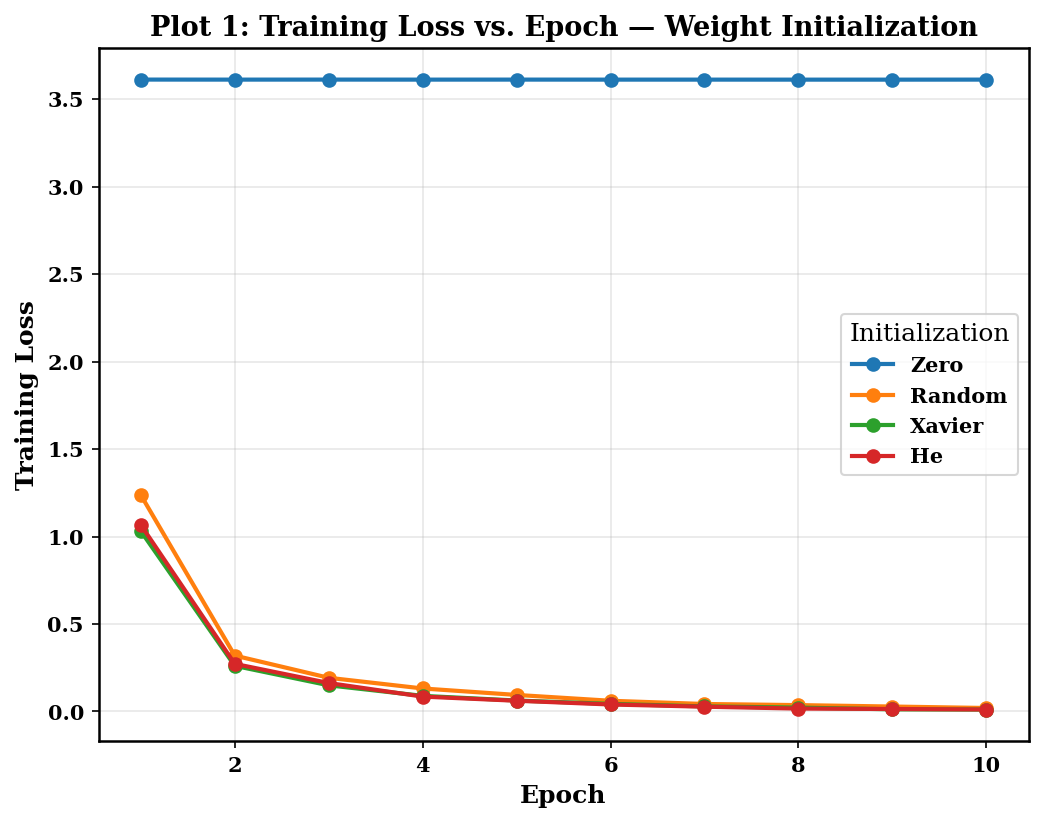

In [20]:

# ---- Plot 1: Training Loss vs. Epoch for each initialization ----
fig, ax = plt.subplots(figsize=(8, 6))
for name, h in init_histories.items():
    ax.plot(range(1, len(h["loss"]) + 1), h["loss"], marker="o", label=name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title("Plot 1: Training Loss vs. Epoch — Weight Initialization")
ax.legend(title="Initialization")
ax.grid(alpha=0.3)
style_axes(ax)
save_fig(fig, "plot1_training_loss_initialization")
plt.show()


Saved: ./figures/plot2_val_accuracy_initialization.eps  |  ./figures/plot2_val_accuracy_initialization.png


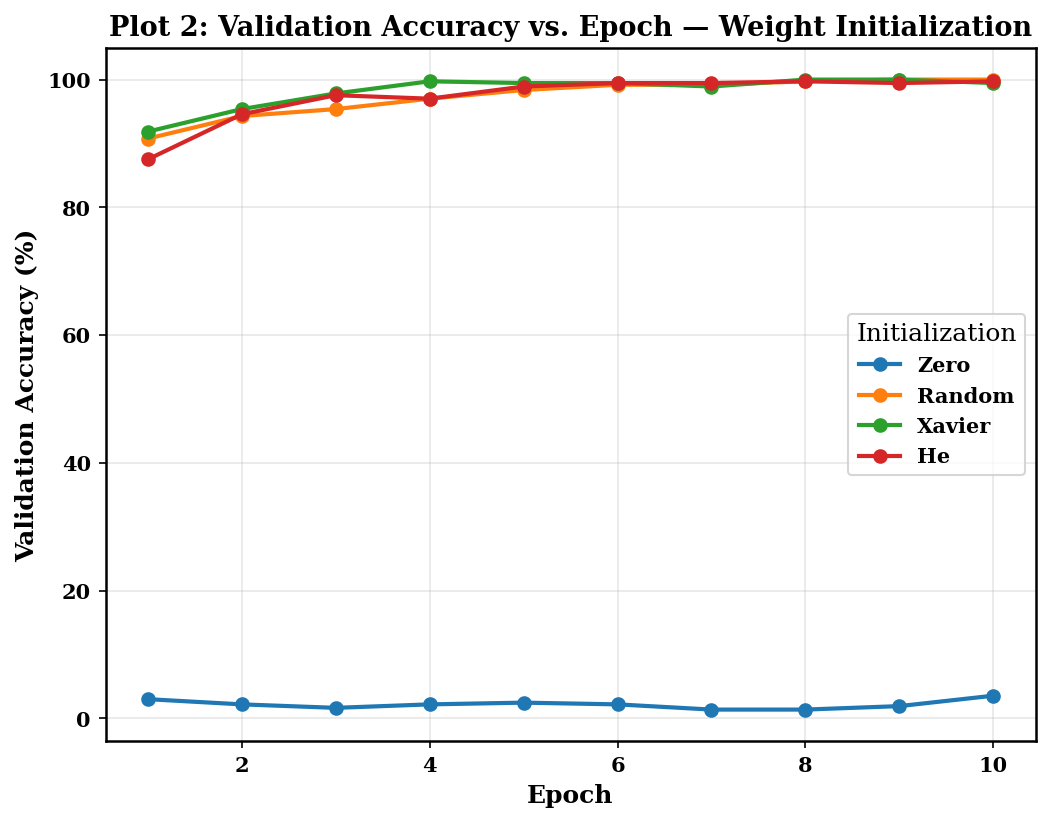

In [21]:

# ---- Plot 2: Validation Accuracy vs. Epoch for each initialization ----
fig, ax = plt.subplots(figsize=(8, 6))
for name, h in init_histories.items():
    ax.plot(range(1, len(h["val_accuracy"]) + 1),
            [v * 100 for v in h["val_accuracy"]], marker="o", label=name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 2: Validation Accuracy vs. Epoch — Weight Initialization")
ax.legend(title="Initialization")
ax.grid(alpha=0.3)
style_axes(ax)
save_fig(fig, "plot2_val_accuracy_initialization")
plt.show()



**Inference (Plots 1 & 2):** *[To be completed after running: identify which initialization converges
fastest and most stably; explain why zero initialization typically underperforms due to symmetric
gradients, while Xavier/He initialization scale variance appropriately for the activation function used.]*



## 6. Regularization and Overfitting

Overfitting occurs when a model performs very well on the training data but generalizes poorly to
unseen data. We compare:
- No regularization
- L2 regularization
- Dropout
- Batch Normalization

### Plot 3 — Training & Validation Accuracy vs. Epoch
### Plot 4 — Training & Validation Loss vs. Epoch


In [22]:

REG_EPOCHS = EPOCHS["reg"]
best_init = keras.initializers.HeNormal(seed=SEED)  # carry forward best initializer from Section 5

reg_configs = {
    "No Regularization": dict(dropout_rate=0.0, use_bn=False, l2_reg=0.0),
    "L2 Regularization": dict(dropout_rate=0.0, use_bn=False, l2_reg=1e-3),
    "Dropout":            dict(dropout_rate=0.5, use_bn=False, l2_reg=0.0),
    "Batch Normalization": dict(dropout_rate=0.0, use_bn=True,  l2_reg=0.0),
}

reg_histories = {}
for name, cfg in reg_configs.items():
    print(f"\n=== Training with {name} ===")
    tf.random.set_seed(SEED)
    model = build_model_with_init(best_init, **cfg)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                   loss="categorical_crossentropy", metrics=["accuracy"])
    hist = model.fit(train_ds, validation_data=val_ds, epochs=REG_EPOCHS, verbose=1)
    reg_histories[name] = hist.history
    free_memory(model)



=== Training with No Regularization ===
Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 28s 157ms/step - accuracy: 0.7249 - loss: 1.0154 - val_accuracy: 0.8859 - val_loss: 0.3329
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.9161 - loss: 0.2667 - val_accuracy: 0.9565 - val_loss: 0.1693
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.9532 - loss: 0.1504 - val_accuracy: 0.9674 - val_loss: 0.1273
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.9725 - loss: 0.0937 - val_accuracy: 0.9918 - val_loss: 0.0515
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.9909 - loss: 0.0510 - val_accuracy: 0.9946 - val_loss: 0.0321
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.9915 - loss: 0.0414 - val_accuracy: 0.9973 - val_loss: 0.0323
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.9967 - loss: 0.0229 - val_accuracy: 1.0000 - val_loss: 0.0175
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step -

Saved: ./figures/plot3_train_val_accuracy_regularization.eps  |  ./figures/plot3_train_val_accuracy_regularization.png


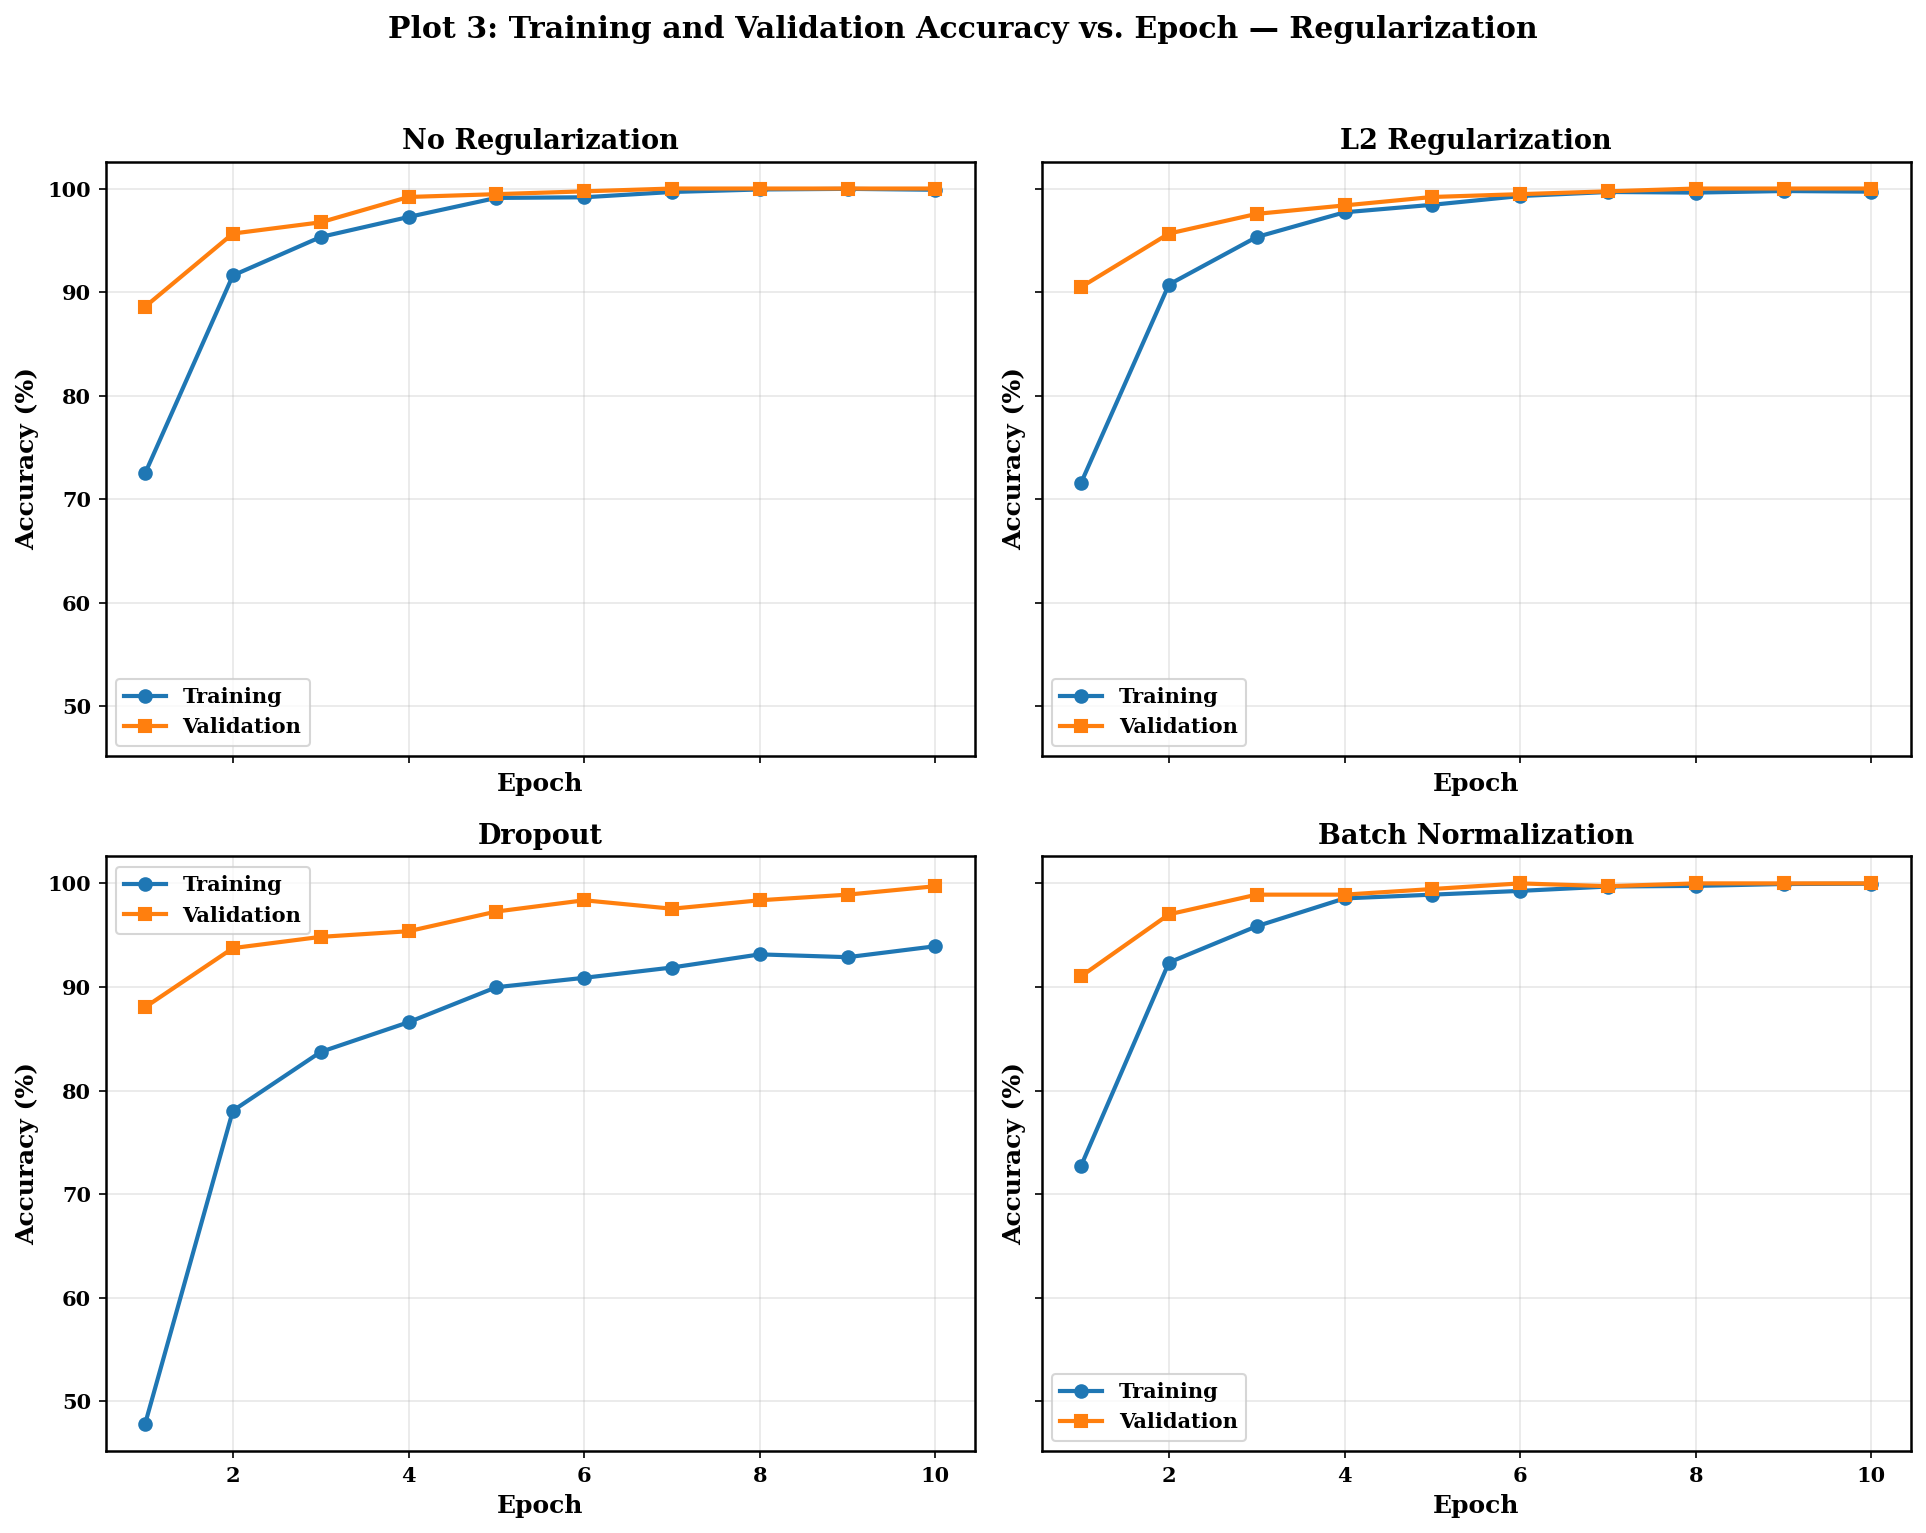

In [23]:

# ---- Plot 3: Training & Validation Accuracy vs. Epoch (one panel per configuration) ----
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)
for ax, (name, h) in zip(axes.flat, reg_histories.items()):
    epochs_range = range(1, len(h["accuracy"]) + 1)
    ax.plot(epochs_range, [v * 100 for v in h["accuracy"]], marker="o", label="Training")
    ax.plot(epochs_range, [v * 100 for v in h["val_accuracy"]], marker="s", label="Validation")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.legend()
    ax.grid(alpha=0.3)
    style_axes(ax)
fig.suptitle("Plot 3: Training and Validation Accuracy vs. Epoch — Regularization", fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "plot3_train_val_accuracy_regularization")
plt.show()


Saved: ./figures/plot4_train_val_loss_regularization.eps  |  ./figures/plot4_train_val_loss_regularization.png


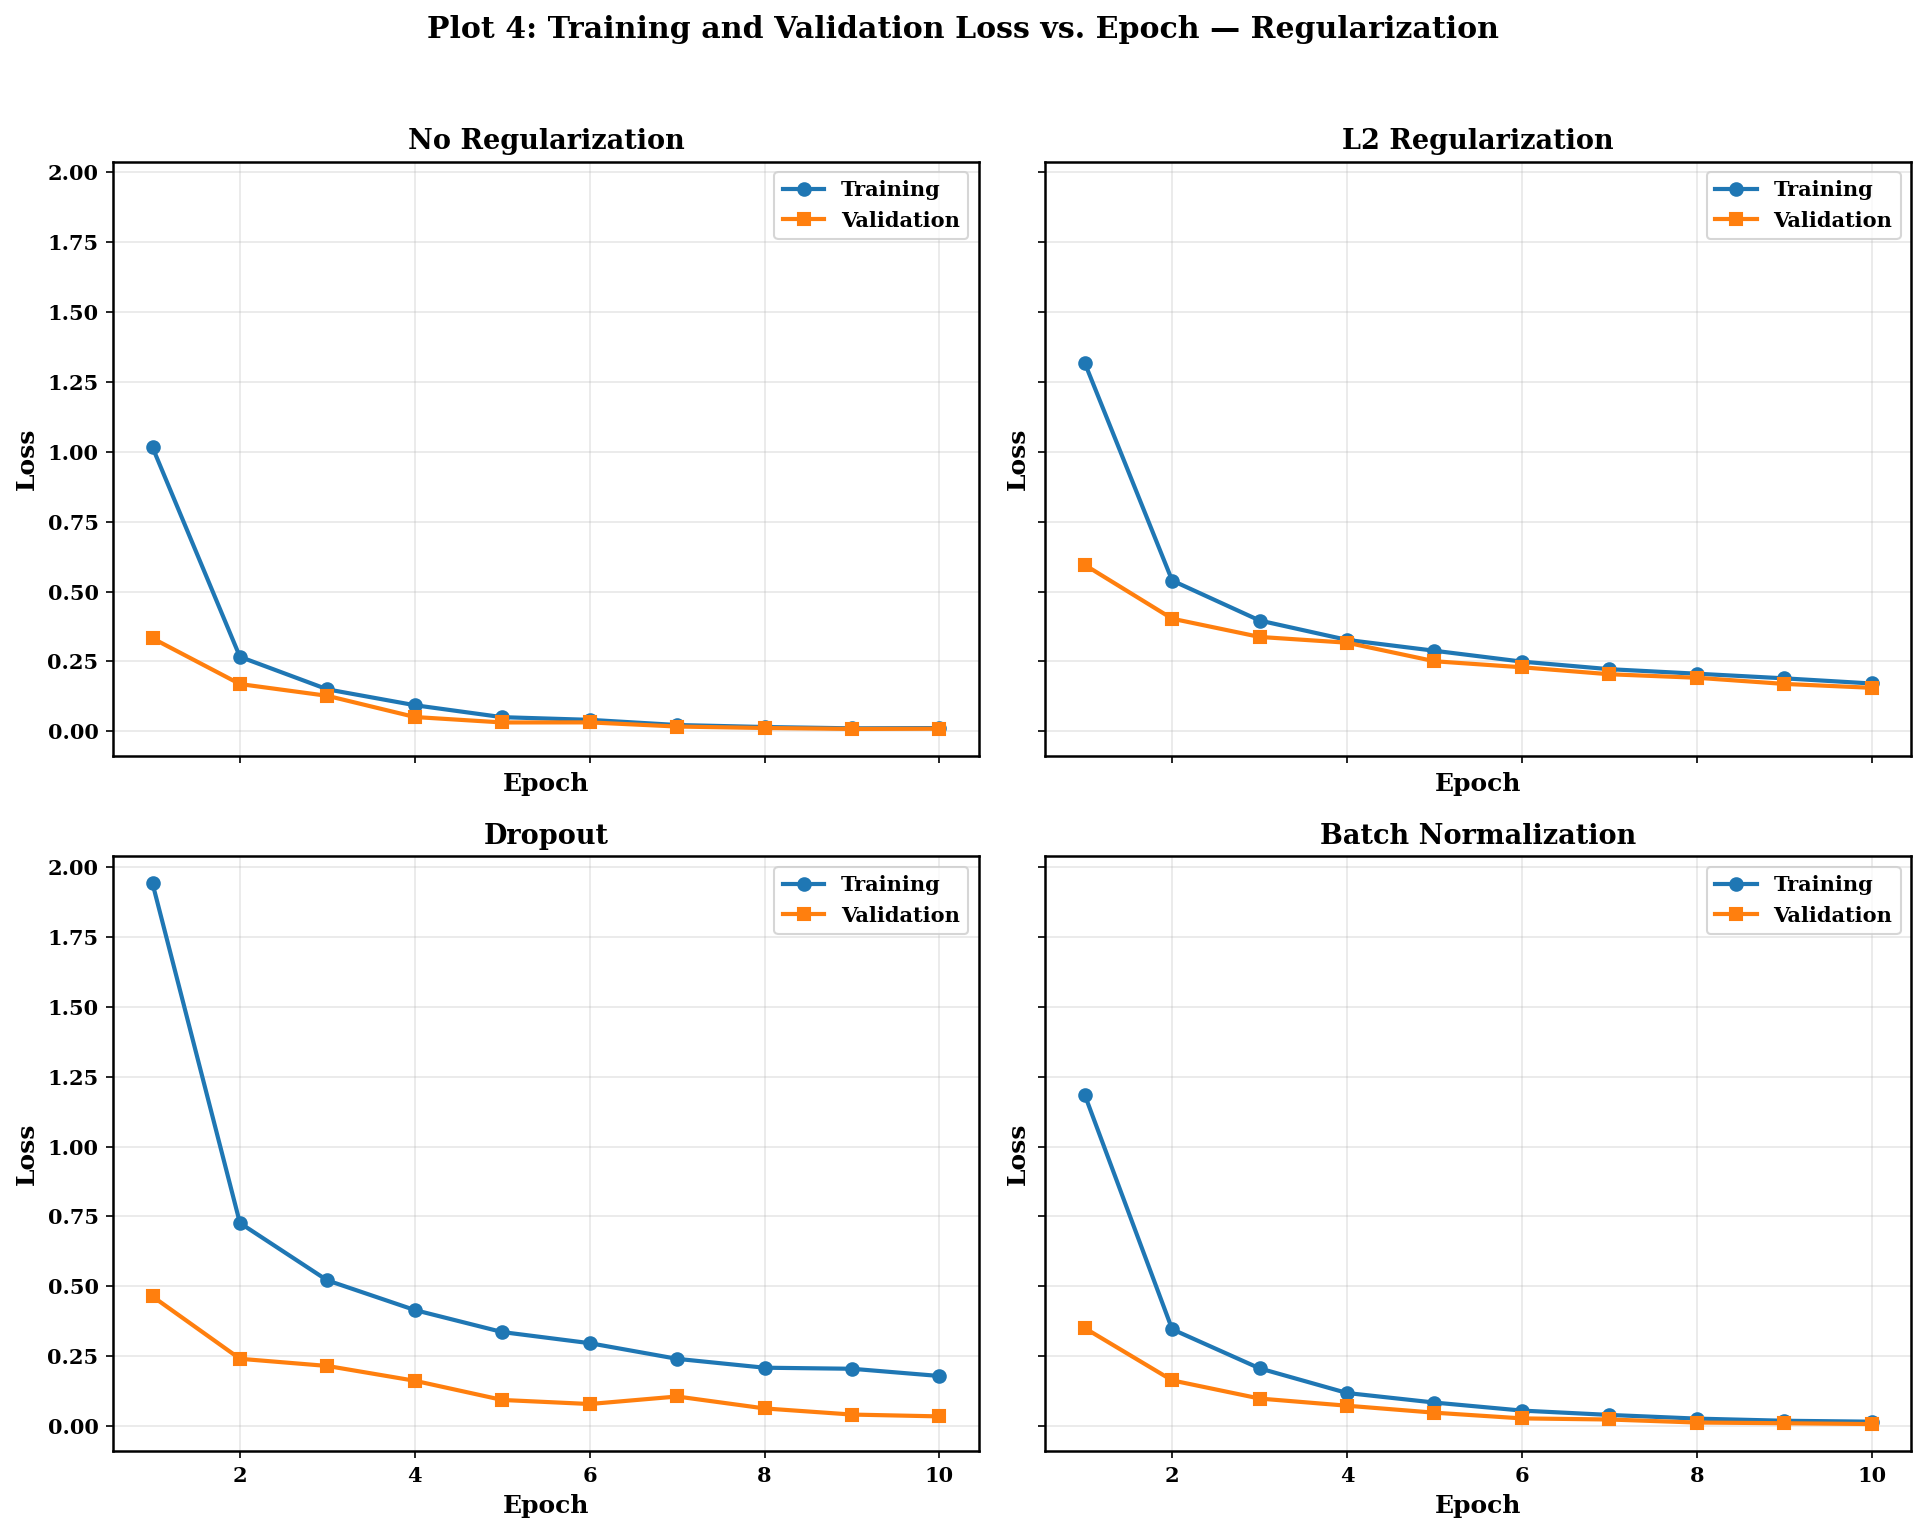

In [24]:

# ---- Plot 4: Training & Validation Loss vs. Epoch (one panel per configuration) ----
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)
for ax, (name, h) in zip(axes.flat, reg_histories.items()):
    epochs_range = range(1, len(h["loss"]) + 1)
    ax.plot(epochs_range, h["loss"], marker="o", label="Training")
    ax.plot(epochs_range, h["val_loss"], marker="s", label="Validation")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)
    style_axes(ax)
fig.suptitle("Plot 4: Training and Validation Loss vs. Epoch — Regularization", fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "plot4_train_val_loss_regularization")
plt.show()



**Inference (Plots 3 & 4):** *[To be completed after running: identify the generalization gap
(train − val accuracy) for each configuration, and note whether validation loss begins to rise while
training loss keeps falling — the signature of overfitting — for the "No Regularization" case
relative to Dropout / L2 / BatchNorm.]*



## 7. Batch Normalization

Batch Normalization normalizes activations within a mini-batch during training.

For a mini-batch $x_1, x_2, \dots, x_m$, the batch mean is

$$\mu_B = \frac{1}{m}\sum_{i=1}^{m} x_i$$

and the batch variance is

$$\sigma_B^2 = \frac{1}{m}\sum_{i=1}^{m} (x_i - \mu_B)^2.$$

The normalized activation is

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}.$$

The final output is

$$y_i = \gamma \hat{x}_i + \beta,$$

where $\gamma$ and $\beta$ are learnable parameters.

### Numerical Example

Consider $x = [2, 4, 6, 8]$.


In [25]:

# Numerical Batch Normalization example (verifies the manual's worked example)
x = np.array([2, 4, 6, 8], dtype=float)
mu_B = x.mean()
var_B = x.var()  # population variance (ddof=0), matches manual's formula
eps = 1e-8

x_hat = (x - mu_B) / np.sqrt(var_B + eps)
gamma, beta = 1.0, 0.0
y = gamma * x_hat + beta

print(f"mu_B    = {mu_B}")
print(f"var_B   = {var_B}")
print(f"std_B   = {np.sqrt(var_B):.3f}")
print(f"x_hat   = {np.round(x_hat, 3)}")
print(f"y (gamma=1, beta=0) = {np.round(y, 3)}")


mu_B    = 5.0
var_B   = 5.0
std_B   = 2.236
x_hat   = [-1.342 -0.447  0.447  1.342]
y (gamma=1, beta=0) = [-1.342 -0.447  0.447  1.342]



**Inference:** Batch Normalization produces approximately zero-centred and unit-scaled activations for
this mini-batch. The learnable $\gamma$ and $\beta$ allow the network to learn an appropriate scale and
shift.

### Plot 5 — With vs. Without Batch Normalization


Saved: ./figures/plot5_with_without_bn.eps  |  ./figures/plot5_with_without_bn.png


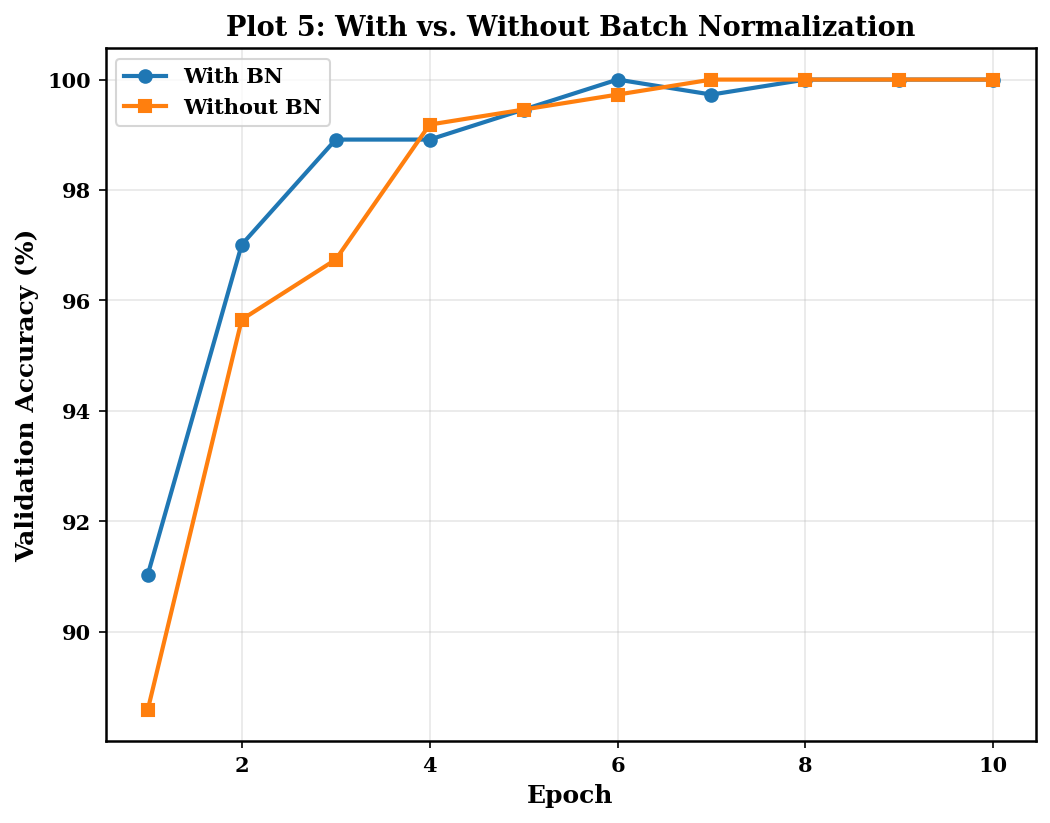

In [26]:

# Plot 5 reuses the histories already collected in Section 6
fig, ax = plt.subplots(figsize=(8, 6))
h_bn = reg_histories["Batch Normalization"]
h_no_bn = reg_histories["No Regularization"]

ax.plot(range(1, len(h_bn["val_accuracy"]) + 1),
        [v * 100 for v in h_bn["val_accuracy"]], marker="o", label="With BN")
ax.plot(range(1, len(h_no_bn["val_accuracy"]) + 1),
        [v * 100 for v in h_no_bn["val_accuracy"]], marker="s", label="Without BN")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 5: With vs. Without Batch Normalization")
ax.legend()
ax.grid(alpha=0.3)
style_axes(ax)
save_fig(fig, "plot5_with_without_bn")
plt.show()



**Inference (Plot 5):** *[To be completed after running: comment on whether BatchNorm accelerates
convergence and/or stabilizes validation accuracy relative to the no-BN baseline.]*



## 8. Optimization Algorithms

We compare **SGD, Momentum, RMSProp and Adam** to study convergence speed, stability and final
validation performance.

### Plot 6 — Training Loss vs. Epoch (one curve per optimizer)
### Plot 7 — Validation Accuracy vs. Epoch (one curve per optimizer)


In [27]:

OPT_EPOCHS = EPOCHS["opt"]
best_reg_cfg = dict(dropout_rate=0.5, use_bn=True, l2_reg=0.0)  # carry forward BN + Dropout

optimizers_to_test = {
    "SGD":      optimizers.SGD(learning_rate=1e-2),
    "Momentum": optimizers.SGD(learning_rate=1e-2, momentum=0.9),
    "RMSProp":  optimizers.RMSprop(learning_rate=1e-3),
    "Adam":     optimizers.Adam(learning_rate=1e-3),
}

opt_histories = {}
opt_metrics_table = []

for name, opt in optimizers_to_test.items():
    print(f"\n=== Training with {name} optimizer ===")
    tf.random.set_seed(SEED)
    model = build_model_with_init(best_init, **best_reg_cfg)
    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

    t0 = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=OPT_EPOCHS, verbose=1)
    elapsed = time.time() - t0

    opt_histories[name] = hist.history
    best_val_acc = max(hist.history["val_accuracy"])
    epoch_to_converge = int(np.argmax(hist.history["val_accuracy"])) + 1
    final_loss = hist.history["loss"][-1]

    opt_metrics_table.append({
        "Optimizer": name,
        "Final Loss": round(final_loss, 4),
        "Best Val. Accuracy (%)": round(best_val_acc * 100, 2),
        "Epoch to Converge": epoch_to_converge,
        "Time (s)": round(elapsed, 2),
    })

    free_memory(model)

opt_df = pd.DataFrame(opt_metrics_table)
opt_df



=== Training with SGD optimizer ===
Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 29s 158ms/step - accuracy: 0.1757 - loss: 3.2379 - val_accuracy: 0.5897 - val_loss: 1.8974
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.4955 - loss: 1.9212 - val_accuracy: 0.8016 - val_loss: 1.1462
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.6374 - loss: 1.4361 - val_accuracy: 0.8668 - val_loss: 0.8485
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.7098 - loss: 1.1743 - val_accuracy: 0.8995 - val_loss: 0.6658
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.7539 - loss: 1.0079 - val_accuracy: 0.8750 - val_loss: 0.6057
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.7669 - loss: 0.9249 - val_accuracy: 0.8886 - val_loss: 0.5226
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.8019 - loss: 0.8087 - val_accuracy: 0.9185 - val_loss: 0.4241
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - acc

,Optimizer,Final Loss,Best Val. Accuracy (%),Epoch to Converge,Time (s)
0,SGD,0.6675,94.29,10,99.43
1,Momentum,0.1925,99.46,9,102.73
2,RMSProp,0.1342,100.00,10,102.81
3,Adam,0.1595,100.00,10,103.61


Saved: ./figures/plot6_training_loss_optimizers.eps  |  ./figures/plot6_training_loss_optimizers.png


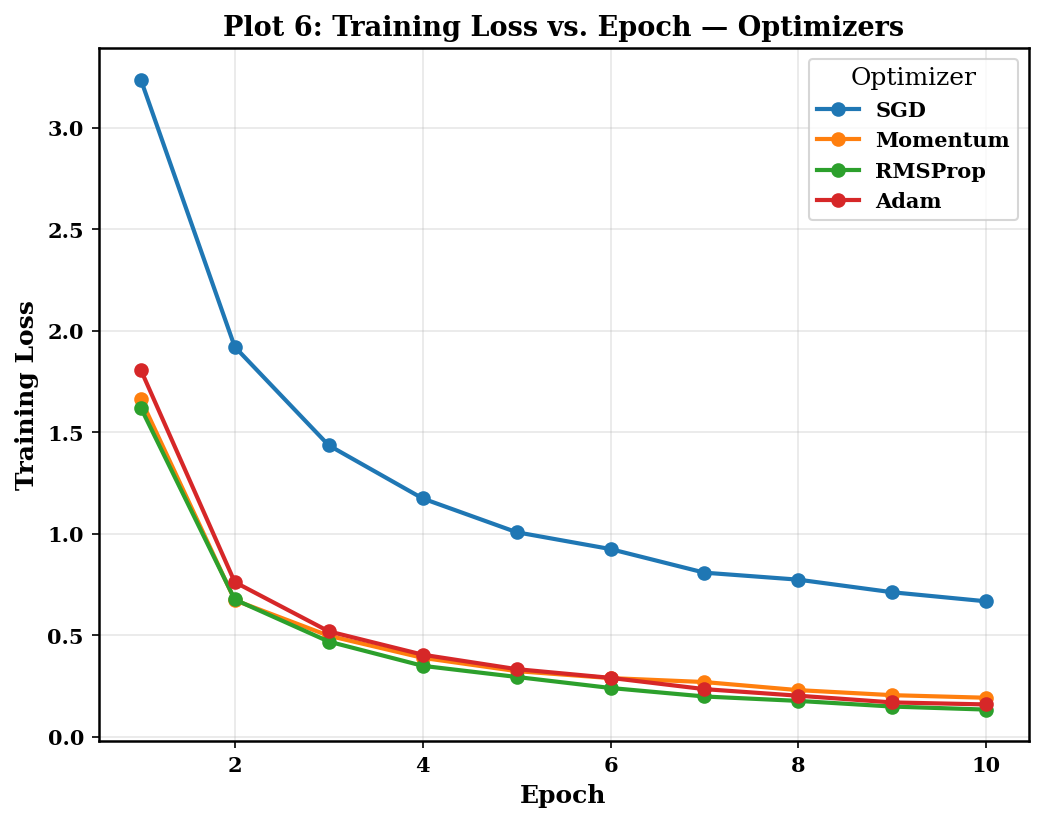

In [28]:

# ---- Plot 6: Training Loss vs. Epoch for Different Optimizers ----
fig, ax = plt.subplots(figsize=(8, 6))
for name, h in opt_histories.items():
    ax.plot(range(1, len(h["loss"]) + 1), h["loss"], marker="o", label=name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title("Plot 6: Training Loss vs. Epoch — Optimizers")
ax.legend(title="Optimizer")
ax.grid(alpha=0.3)
style_axes(ax)
save_fig(fig, "plot6_training_loss_optimizers")
plt.show()


Saved: ./figures/plot7_val_accuracy_optimizers.eps  |  ./figures/plot7_val_accuracy_optimizers.png


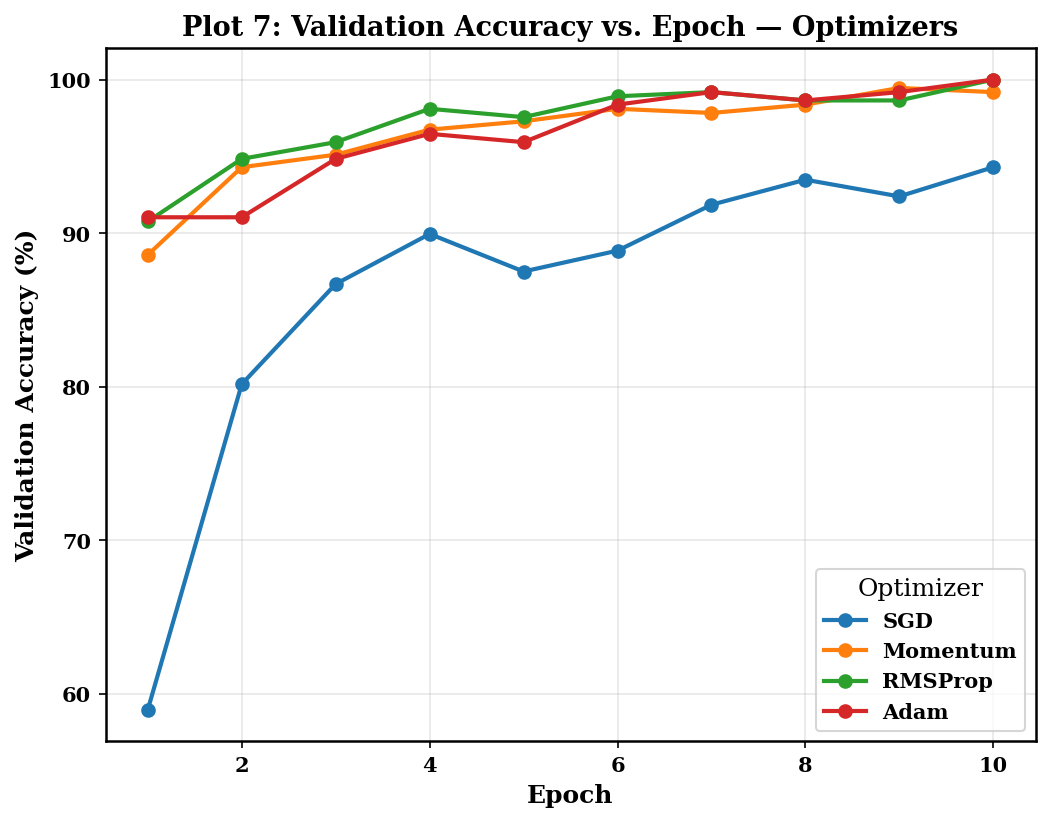

In [29]:

# ---- Plot 7: Validation Accuracy vs. Epoch for Different Optimizers ----
fig, ax = plt.subplots(figsize=(8, 6))
for name, h in opt_histories.items():
    ax.plot(range(1, len(h["val_accuracy"]) + 1),
            [v * 100 for v in h["val_accuracy"]], marker="o", label=name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 7: Validation Accuracy vs. Epoch — Optimizers")
ax.legend(title="Optimizer")
ax.grid(alpha=0.3)
style_axes(ax)
save_fig(fig, "plot7_val_accuracy_optimizers")
plt.show()



**Table: Optimizer Comparison**
*(populated programmatically above as `opt_df` — Final Loss, Best Validation Accuracy, Epoch to
Converge, Training Time)*

**Inference (Plots 6 & 7):** *[To be completed after running: compare convergence speed and stability
of SGD, Momentum, RMSProp and Adam, and identify which optimizer gives the best trade-off between
convergence speed and final accuracy.]*



## 9. CNN Hyperparameter Tuning

| Hyperparameter | Suggested Values |
|---|---|
| Learning Rate | 0.001, 0.0001 |
| Batch Size | 16, 32, 64 |
| Dropout Rate | 0, 0.25, 0.5 |
| Optimizer | SGD, Adam |
| Fine-Tuning Learning Rate | $10^{-4}$, $10^{-5}$ |
| Frozen Layers | Frozen base / Partial unfreezing |

For a convolution operation, the output dimension is

$$O = \left\lfloor \frac{N + 2P - K}{S} \right\rfloor + 1,$$

where $N$ is input size, $K$ is kernel size, $P$ is padding and $S$ is stride.

**Experimental rule:** During a controlled hyperparameter study, change **one** hyperparameter at a
time while keeping the remaining settings fixed.

### Plot 8 — Learning Rate vs. Validation Accuracy
### Plot 9 — Batch Size vs. Validation Accuracy
### Plot 10 — Dropout Rate vs. Validation Accuracy


In [30]:

HP_EPOCHS = EPOCHS["hp"]
best_optimizer_name = opt_df.loc[opt_df["Best Val. Accuracy (%)"].idxmax(), "Optimizer"]
print(f"Best optimizer carried forward from Section 8: {best_optimizer_name}")

def make_optimizer(name, lr):
    return {
        "SGD": optimizers.SGD(learning_rate=lr),
        "Momentum": optimizers.SGD(learning_rate=lr, momentum=0.9),
        "RMSProp": optimizers.RMSprop(learning_rate=lr),
        "Adam": optimizers.Adam(learning_rate=lr),
    }[name]

def run_single_config(lr=1e-3, batch_size=32, dropout_rate=0.5, epochs=HP_EPOCHS):
    tf.random.set_seed(SEED)
    tds = make_pipeline(ds_train_raw, batch_size=batch_size, augment=True, shuffle=True)
    vds = make_pipeline(ds_val_raw, batch_size=batch_size, augment=False, shuffle=False)
    model = build_model_with_init(best_init, dropout_rate=dropout_rate, use_bn=True)
    model.compile(optimizer=make_optimizer(best_optimizer_name, lr),
                   loss="categorical_crossentropy", metrics=["accuracy"])
    hist = model.fit(tds, validation_data=vds, epochs=epochs, verbose=0)
    best_val_acc = max(hist.history["val_accuracy"]) * 100
    free_memory(model)
    return best_val_acc

# --- Plot 8: Learning Rate sweep ---
learning_rates = [1e-3, 1e-4]
lr_results = {lr: run_single_config(lr=lr) for lr in learning_rates}
print("Learning rate sweep:", lr_results)


Best optimizer carried forward from Section 8: RMSProp
Learning rate sweep: {0.001: 100.0, 0.0001: 94.021737575531}


Saved: ./figures/plot8_lr_vs_val_accuracy.eps  |  ./figures/plot8_lr_vs_val_accuracy.png


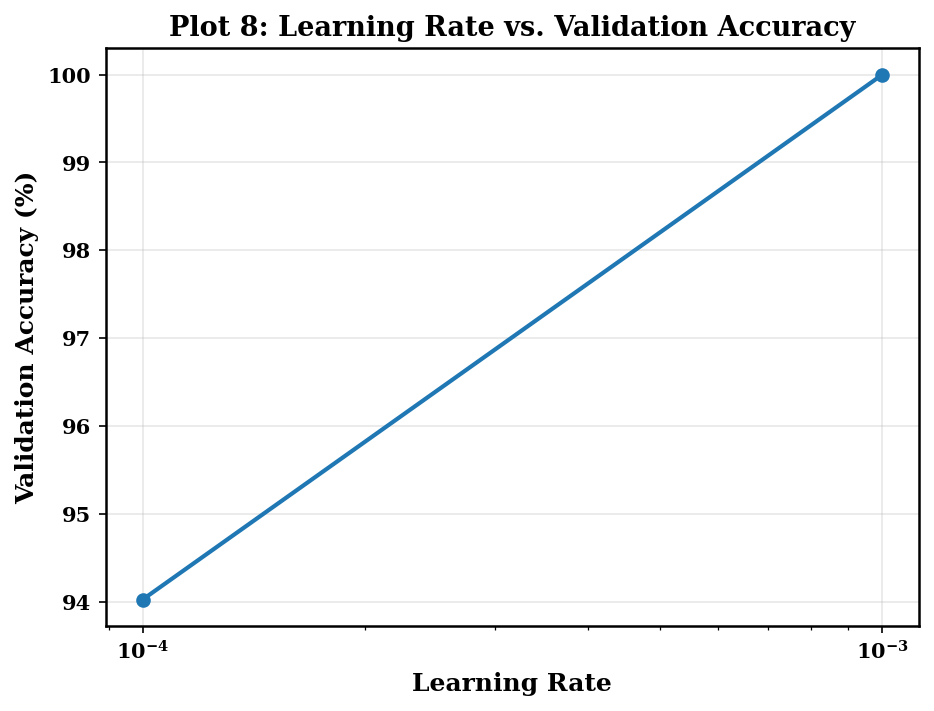

In [31]:

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(list(lr_results.keys()), list(lr_results.values()), marker="o", linestyle="-")
ax.set_xscale("log")
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 8: Learning Rate vs. Validation Accuracy")
ax.grid(alpha=0.3)
style_axes(ax)
save_fig(fig, "plot8_lr_vs_val_accuracy")
plt.show()


2026-08-30 11:00:21.554679: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 11:00:21.692973: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 11:00:34.832544: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 11:00:34.970730: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Batch size sweep: {16: 100.0, 32: 99.45651888847351, 64: 99.45651888847351}
Saved: ./figures/plot9_batchsize_vs_val_accuracy.eps  |  ./figures/plot9_batchsize_vs_val_accuracy.png


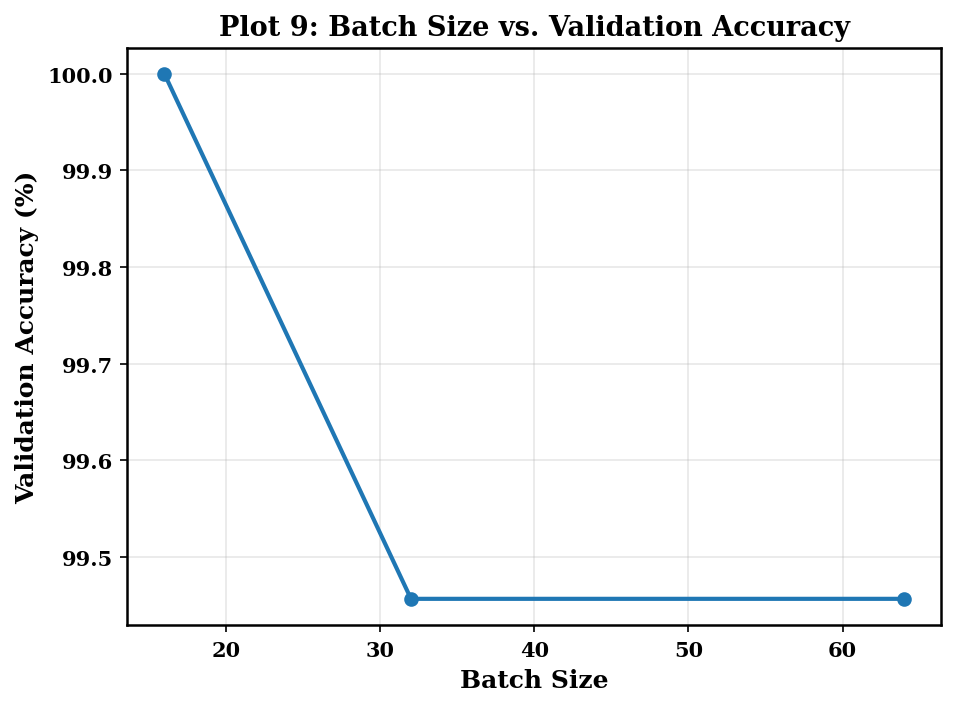

In [32]:

# --- Plot 9: Batch Size sweep ---
batch_sizes = [16, 32, 64]
bs_results = {bs: run_single_config(batch_size=bs) for bs in batch_sizes}
print("Batch size sweep:", bs_results)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(list(bs_results.keys()), list(bs_results.values()), marker="o", linestyle="-")
ax.set_xlabel("Batch Size")
ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 9: Batch Size vs. Validation Accuracy")
ax.grid(alpha=0.3)
style_axes(ax)
save_fig(fig, "plot9_batchsize_vs_val_accuracy")
plt.show()


Dropout rate sweep: {0.0: 100.0, 0.25: 100.0, 0.5: 99.45651888847351}
Saved: ./figures/plot10_dropout_vs_val_accuracy.eps  |  ./figures/plot10_dropout_vs_val_accuracy.png


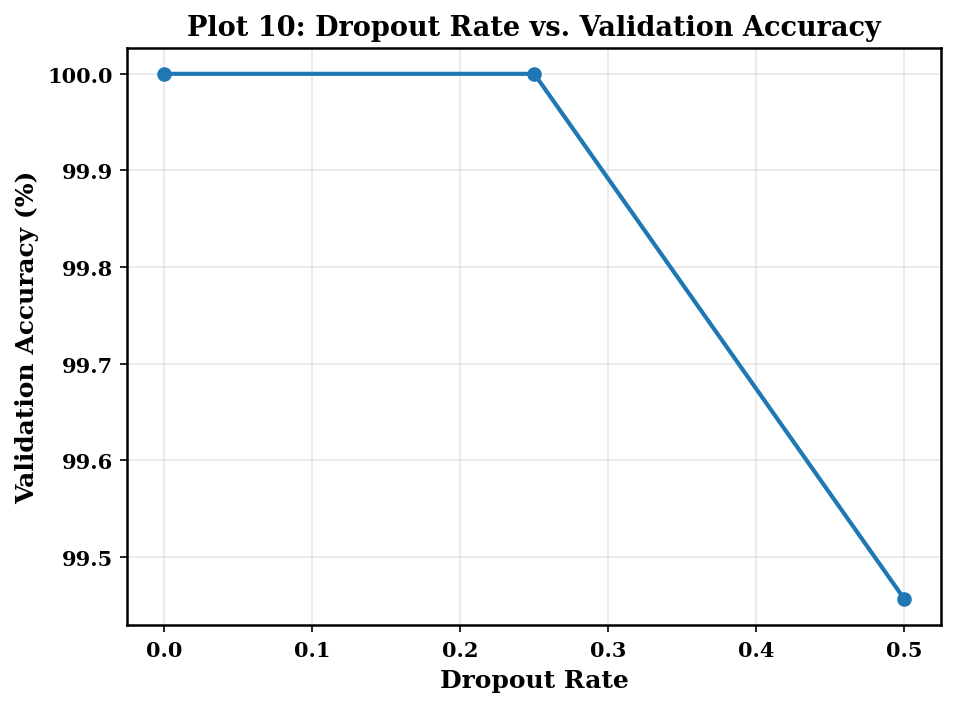

In [33]:

# --- Plot 10: Dropout Rate sweep ---
dropout_rates = [0.0, 0.25, 0.5]
dr_results = {dr: run_single_config(dropout_rate=dr) for dr in dropout_rates}
print("Dropout rate sweep:", dr_results)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(list(dr_results.keys()), list(dr_results.values()), marker="o", linestyle="-")
ax.set_xlabel("Dropout Rate")
ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 10: Dropout Rate vs. Validation Accuracy")
ax.grid(alpha=0.3)
style_axes(ax)
save_fig(fig, "plot10_dropout_vs_val_accuracy")
plt.show()



**Inference (Plots 8–10):** *[To be completed after running: discuss the effect of learning rate
(too high → unstable/divergent, too low → slow convergence), batch size (regularization/noise vs.
compute efficiency trade-off), and dropout rate (underfitting at high dropout vs. overfitting at zero
dropout) on validation accuracy.]*



## 10. Transfer Learning and Fine-Tuning

MobileNetV2 pretrained on ImageNet is used.

**Case A — Feature Extraction:**
`Pretrained MobileNetV2 → Freeze Base → New Classifier`
The pretrained convolutional layers are frozen and only the newly added classification layers are trained.

**Case B — Fine-Tuning:**
`Pretrained MobileNetV2 → Unfreeze Selected Layers → Small Learning Rate`
The upper layers of the pretrained network are unfrozen and trained with a smaller learning rate.

### Plot 11 — Feature Extraction vs. Fine-Tuning (Validation Accuracy)
### Plot 12 — Training and Validation Loss (before vs. after fine-tuning)


In [34]:

FE_EPOCHS = EPOCHS["fe"]
FT_EPOCHS = EPOCHS["ft"]
best_batch_size = max(bs_results, key=bs_results.get)
best_dropout = max(dr_results, key=dr_results.get)
best_lr = max(lr_results, key=lr_results.get)

print(f"Carrying forward: batch_size={best_batch_size}, dropout={best_dropout}, lr={best_lr}, "
      f"optimizer={best_optimizer_name}")

train_ds_final = make_pipeline(ds_train_raw, batch_size=best_batch_size, augment=True, shuffle=True)
val_ds_final   = make_pipeline(ds_val_raw, batch_size=best_batch_size, augment=False, shuffle=False)
test_ds_final  = make_pipeline(ds_test, batch_size=best_batch_size, augment=False, shuffle=False)

# ---- Case A: Feature Extraction (frozen base) ----
tf.random.set_seed(SEED)
base_model = MobileNetV2(input_shape=(IMG_SIZE_SWEEP, IMG_SIZE_SWEEP, 3), include_top=False, weights="imagenet")
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE_SWEEP, IMG_SIZE_SWEEP, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, kernel_initializer=best_init)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Dropout(best_dropout)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)
final_model = keras.Model(inputs, outputs)

final_model.compile(optimizer=make_optimizer(best_optimizer_name, best_lr),
                     loss="categorical_crossentropy", metrics=["accuracy"])
final_model.summary()

t0 = time.time()
fe_history = final_model.fit(train_ds_final, validation_data=val_ds_final,
                              epochs=FE_EPOCHS, verbose=1)
fe_time = time.time() - t0
print(f"Feature extraction training time: {fe_time:.2f} s")


Carrying forward: batch_size=16, dropout=0.0, lr=0.001, optimizer=RMSProp


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,596,453 (9.90 MB)

 Trainable params: 337,957 (1.29 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

Epoch 1/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.7953 - loss: 0.7908 - val_accuracy: 0.9266 - val_loss: 0.1906
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9293 - loss: 0.2226 - val_accuracy: 0.9620 - val_loss: 0.1245
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9647 - loss: 0.1181 - val_accuracy: 0.9891 - val_loss: 0.0824
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9804 - loss: 0.0729 - val_accuracy: 0.9946 - val_loss: 0.0259
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9852 - loss: 0.0499 - val_accuracy: 0.9973 - val_loss: 0.0117
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9906 - loss: 0.0368 - val_accuracy: 0.9946 - val_loss: 0.0130
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9964 - loss: 0.0170 - val_accuracy: 0.9973 - val_loss: 0.0110
Epoch 8/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9934 - loss: 0.0240 - val_acc

In [35]:

# ---- Case B: Fine-Tuning (unfreeze last block of MobileNetV2) ----
base_model.trainable = True
FINE_TUNE_FROM = int(len(base_model.layers) * 0.85)  # unfreeze roughly the last 15% of layers
for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

final_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                     loss="categorical_crossentropy", metrics=["accuracy"])

t0 = time.time()
ft_history = final_model.fit(train_ds_final, validation_data=val_ds_final,
                              epochs=FT_EPOCHS, verbose=1)
ft_time = time.time() - t0
print(f"Fine-tuning training time: {ft_time:.2f} s")
print(f"Total training time (feature extraction + fine-tuning): {fe_time + ft_time:.2f} s")


Epoch 1/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.9611 - loss: 0.1288 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9677 - loss: 0.1026 - val_accuracy: 1.0000 - val_loss: 5.0028e-04
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9764 - loss: 0.0822 - val_accuracy: 1.0000 - val_loss: 5.8172e-04
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9807 - loss: 0.0688 - val_accuracy: 1.0000 - val_loss: 6.2345e-04
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9810 - loss: 0.0611 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9810 - loss: 0.0617 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9807 - loss: 0.0619 - val_accuracy: 1.0000 - val_loss: 7.3787e-04
Epoch 8/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9879 - loss: 

Saved: ./figures/plot11_feature_extraction_vs_finetuning.eps  |  ./figures/plot11_feature_extraction_vs_finetuning.png


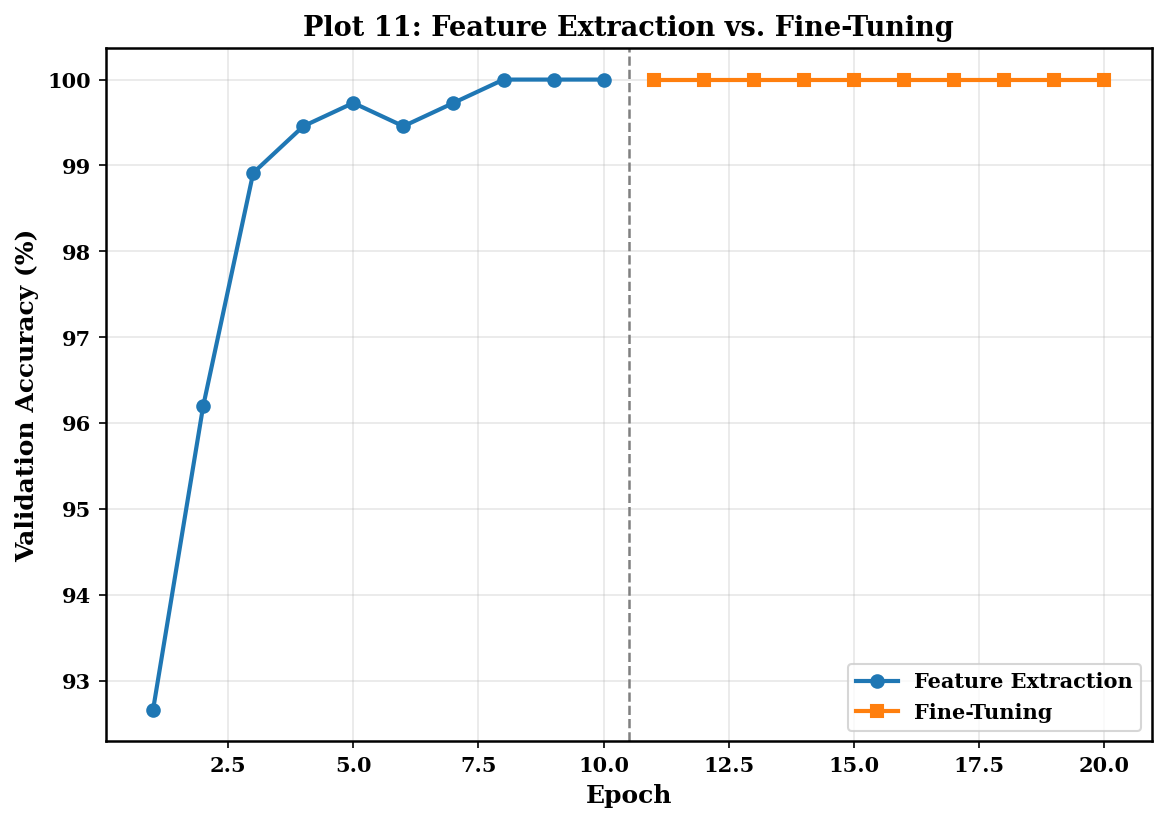

In [36]:

# ---- Plot 11: Feature Extraction vs. Fine-Tuning (Validation Accuracy) ----
fe_val_acc = [v * 100 for v in fe_history.history["val_accuracy"]]
ft_val_acc = [v * 100 for v in ft_history.history["val_accuracy"]]
combined_val_acc = fe_val_acc + ft_val_acc
fe_epochs_n = len(fe_val_acc)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(range(1, fe_epochs_n + 1), fe_val_acc, marker="o", label="Feature Extraction")
ax.plot(range(fe_epochs_n + 1, fe_epochs_n + len(ft_val_acc) + 1), ft_val_acc,
        marker="s", label="Fine-Tuning")
ax.axvline(fe_epochs_n + 0.5, linestyle="--", color="gray", linewidth=1.2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 11: Feature Extraction vs. Fine-Tuning")
ax.legend()
ax.grid(alpha=0.3)
style_axes(ax)
save_fig(fig, "plot11_feature_extraction_vs_finetuning")
plt.show()


Saved: ./figures/plot12_train_val_loss_finetuning.eps  |  ./figures/plot12_train_val_loss_finetuning.png


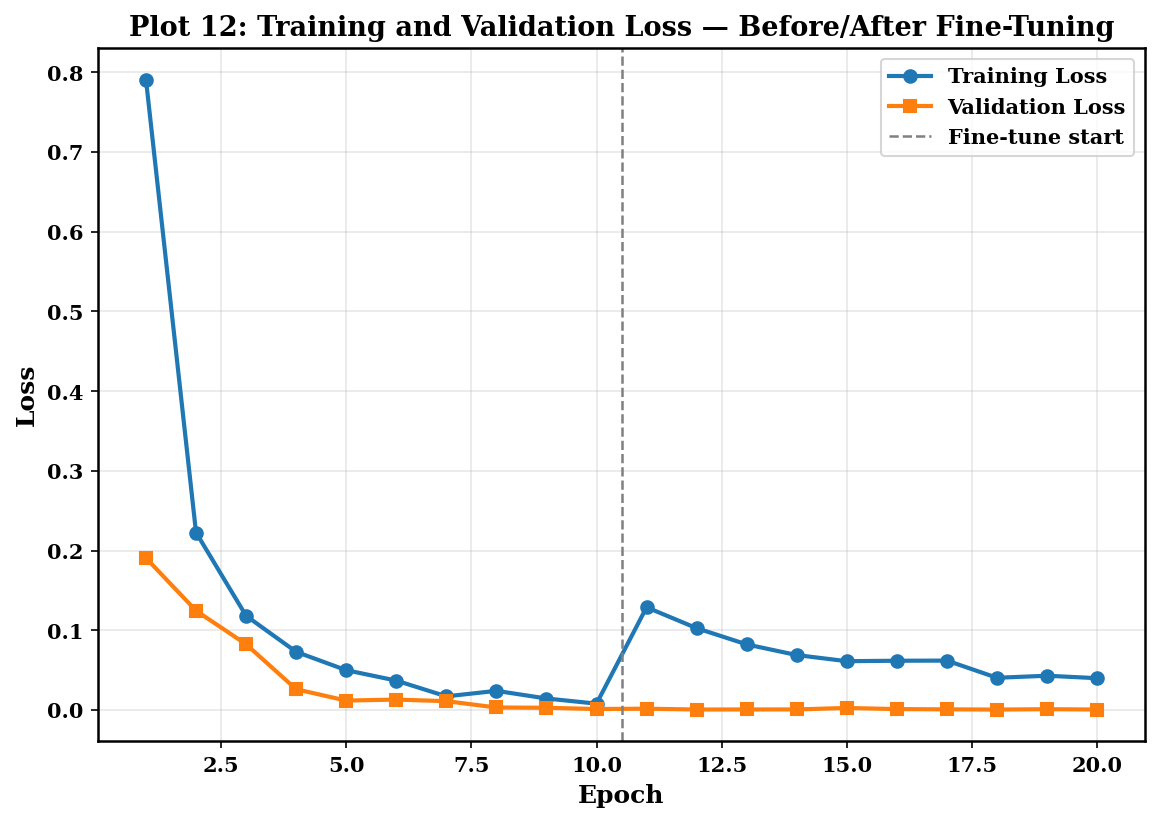

In [37]:

# ---- Plot 12: Training and Validation Loss (before vs. after fine-tuning) ----
combined_train_loss = fe_history.history["loss"] + ft_history.history["loss"]
combined_val_loss = fe_history.history["val_loss"] + ft_history.history["val_loss"]
total_epochs_n = len(combined_train_loss)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(range(1, total_epochs_n + 1), combined_train_loss, marker="o", label="Training Loss")
ax.plot(range(1, total_epochs_n + 1), combined_val_loss, marker="s", label="Validation Loss")
ax.axvline(fe_epochs_n + 0.5, linestyle="--", color="gray", linewidth=1.2, label="Fine-tune start")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Plot 12: Training and Validation Loss — Before/After Fine-Tuning")
ax.legend()
ax.grid(alpha=0.3)
style_axes(ax)
save_fig(fig, "plot12_train_val_loss_finetuning")
plt.show()



**Discussion — Why does fine-tuning normally require a smaller learning rate than training a newly
initialized classifier?**
The pretrained convolutional filters already encode useful, well-conditioned features learned from a
large source dataset (ImageNet). Using a large learning rate during fine-tuning risks large gradient
updates that destructively overwrite these pretrained weights ("catastrophic forgetting"), whereas a
newly initialized classifier head has no useful structure to preserve and therefore benefits from a
larger learning rate to escape random initialization quickly. A small fine-tuning learning rate allows
the unfrozen pretrained layers to adapt gently to the new dataset while retaining their general-purpose
representations.

**Inference (Plots 11 & 12):** *[To be completed after running: quantify the validation-accuracy
improvement from feature-extraction to fine-tuning, and note the transient loss spike (if any) at the
fine-tuning boundary before losses resume decreasing.]*



## 11. K-Fold Cross-Validation

After the individual studies, we select **3–4 promising configurations** and use **5-fold
cross-validation** on the training data.

For $K = 5$,

$$\bar{A} = \frac{1}{5}\sum_{i=1}^{5} A_i \qquad \text{and} \qquad
SD = \sqrt{\frac{1}{5}\sum_{i=1}^{5} (A_i - \bar{A})^2}.$$

Results are reported as $\bar{A} \pm SD$. **The independent test set is not used during
hyperparameter selection.**

### Plot 13 — 5-Fold Cross-Validation Accuracy (with standard-deviation error bars)


In [38]:

CV_EPOCHS = EPOCHS["cv"]
N_FOLDS = 5

# ---------------------------------------------------------------
# STREAMING K-Fold (no full-dataset materialization into RAM):
#
# Instead of loading every image into one big NumPy array (which cost several
# GB of RAM previously and was a leading cause of Kaggle/Colab OOM crashes),
# we only ever keep small integer INDEX arrays in memory. Each fold's data is
# streamed on demand straight from the TFDS source using .skip()/.take() on a
# per-example enumeration, and each fold's tf.data pipeline is disk-cached
# (tf.data .cache() to a temp file) rather than RAM-cached, so peak memory
# stays low regardless of dataset size.
# ---------------------------------------------------------------
CACHE_DIR = "./tfcache"
os.makedirs(CACHE_DIR, exist_ok=True)

n_full = n_train_full
indices = np.arange(n_full)
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# All 4 candidate configurations the manual describes ("select 3-4 promising
# configurations"). N_CV_CONFIGS controls how many are ACTUALLY cross-validated
# in this run (see Section 0): "kaggle" mode runs the first N_CV_CONFIGS only,
# keeping the rest defined for easy expansion to "full" mode later.
_all_candidate_configs = {
    "C1_BestFromSweeps":  dict(optimizer_name=best_optimizer_name, lr=best_lr,
                                dropout_rate=best_dropout, use_bn=True, batch_size=best_batch_size),
    "C2_RMSProp_LightDropout": dict(optimizer_name="RMSProp", lr=1e-3,
                                     dropout_rate=0.25, use_bn=True, batch_size=32),
    "C3_Adam_HighDropout": dict(optimizer_name="Adam", lr=1e-3,
                                 dropout_rate=0.5, use_bn=True, batch_size=32),
    "C4_Adam_LowLR":       dict(optimizer_name="Adam", lr=1e-4,
                                 dropout_rate=0.5, use_bn=True, batch_size=32),
}
candidate_configs = dict(list(_all_candidate_configs.items())[:N_CV_CONFIGS])
print(f"Running 5-fold CV on {len(candidate_configs)} configuration(s): {list(candidate_configs.keys())}")
if N_CV_CONFIGS < 4:
    print(f"({4 - N_CV_CONFIGS} additional pre-defined configuration(s) skipped in '{RUN_MODE}' mode "
          f"to stay within compute budget -- set RUN_MODE='full' in Section 0 to run all 4.)")

# ds_train_full was already shuffled once with a fixed SEED in Section 3, so
# the example at position i is stable across enumerations -- this is what
# makes index-based streaming splits valid without ever loading everything.
_indexed_train_full = ds_train_full.enumerate()

def _is_in(idx_tensor, lookup_tensor):
    return tf.reduce_any(tf.equal(lookup_tensor, idx_tensor))

def get_fold_datasets(fold_train_idx, fold_val_idx, batch_size, fold_tag):
    # Small lookup tensors only (a few thousand ints) -- not the images themselves.
    train_lookup = tf.constant(fold_train_idx, dtype=tf.int64)
    val_lookup = tf.constant(fold_val_idx, dtype=tf.int64)

    fold_train_raw = (_indexed_train_full
                       .filter(lambda i, data: _is_in(i, train_lookup))
                       .map(lambda i, data: data))
    fold_val_raw = (_indexed_train_full
                     .filter(lambda i, data: _is_in(i, val_lookup))
                     .map(lambda i, data: data))

    ftr = fold_train_raw.map(lambda x, y: preprocess(x, y, augment=True),
                              num_parallel_calls=tf.data.AUTOTUNE)
    # Disk-backed cache (NOT RAM cache): after the first epoch, decoded/resized
    # tensors for this fold are read back from disk instead of RAM or being
    # re-decoded from the source, which keeps repeat-epoch cost low without
    # holding the fold in memory.
    ftr = ftr.cache(os.path.join(CACHE_DIR, f"train_{fold_tag}"))
    ftr = ftr.shuffle(1024, seed=SEED).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    fva = fold_val_raw.map(lambda x, y: preprocess(x, y, augment=False),
                            num_parallel_calls=tf.data.AUTOTUNE)
    fva = fva.cache(os.path.join(CACHE_DIR, f"val_{fold_tag}"))
    fva = fva.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return ftr, fva

def clear_fold_cache(fold_tag):
    # Remove this fold's on-disk cache files once training on it is done, so
    # disk usage does not grow unbounded across 5 folds x 4-6 configs.
    for prefix in ("train_", "val_"):
        for suffix in ("", ".index", ".data-00000-of-00001", "-tempstate*"):
            path_pattern = os.path.join(CACHE_DIR, f"{prefix}{fold_tag}{suffix}")
            for p in __import__("glob").glob(path_pattern):
                try:
                    os.remove(p)
                except OSError:
                    pass



Running 5-fold CV on 3 configuration(s): ['C1_BestFromSweeps', 'C2_RMSProp_LightDropout', 'C3_Adam_HighDropout']
(1 additional pre-defined configuration(s) skipped in 'kaggle' mode to stay within compute budget -- set RUN_MODE='full' in Section 0 to run all 4.)


In [39]:

cv_results = {name: [] for name in candidate_configs}

for cfg_name, cfg in candidate_configs.items():
    print(f"\n########## Cross-validating configuration: {cfg_name} ##########")
    fold_accs = []
    for fold_i, (train_idx, val_idx) in enumerate(kf.split(indices), start=1):
        print(f"  -- Fold {fold_i}/{N_FOLDS} --")
        fold_tag = f"{cfg_name}_fold{fold_i}"
        tf.random.set_seed(SEED + fold_i)
        ftr_ds, fva_ds = get_fold_datasets(train_idx, val_idx, cfg["batch_size"], fold_tag)

        model = build_model_with_init(best_init, dropout_rate=cfg["dropout_rate"],
                                       use_bn=cfg["use_bn"])
        model.compile(optimizer=make_optimizer(cfg["optimizer_name"], cfg["lr"]),
                       loss="categorical_crossentropy", metrics=["accuracy"])
        hist = model.fit(ftr_ds, validation_data=fva_ds, epochs=CV_EPOCHS, verbose=0)
        fold_val_acc = max(hist.history["val_accuracy"]) * 100
        fold_accs.append(fold_val_acc)
        print(f"     Fold {fold_i} validation accuracy: {fold_val_acc:.2f}%")

        free_memory(model, ftr_ds, fva_ds)
        clear_fold_cache(fold_tag)  # remove this fold's disk cache before the next one

    cv_results[cfg_name] = fold_accs
    print(f"  {cfg_name}: {np.mean(fold_accs):.2f}% \u00b1 {np.std(fold_accs):.2f}%")
    save_json(cv_results, "cv_results_partial")
    print_memory(f"after {cfg_name}")



########## Cross-validating configuration: C1_BestFromSweeps ##########
  -- Fold 1/5 --


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


     Fold 1 validation accuracy: 98.37%
  -- Fold 2/5 --
     Fold 2 validation accuracy: 97.69%
  -- Fold 3/5 --
     Fold 3 validation accuracy: 97.55%
  -- Fold 4/5 --
     Fold 4 validation accuracy: 98.23%
  -- Fold 5/5 --
     Fold 5 validation accuracy: 97.83%
  C1_BestFromSweeps: 97.93% ± 0.31%
Saved results: ./results/cv_results_partial.json
[MEM - after C1_BestFromSweeps] Process RAM: 17.23 GB
[MEM - after C1_BestFromSweeps] GPU current: 0.42 GB | peak: 1.57 GB

########## Cross-validating configuration: C2_RMSProp_LightDropout ##########
  -- Fold 1/5 --
     Fold 1 validation accuracy: 97.15%
  -- Fold 2/5 --
     Fold 2 validation accuracy: 97.15%
  -- Fold 3/5 --
     Fold 3 validation accuracy: 98.37%
  -- Fold 4/5 --
     Fold 4 validation accuracy: 98.23%
  -- Fold 5/5 --
     Fold 5 validation accuracy: 98.64%
  C2_RMSProp_LightDropout: 97.91% ± 0.63%
Saved results: ./results/cv_results_partial.json
[MEM - after C2_RMSProp_LightDropout] Process RAM: 18.66 GB
[MEM - af

In [40]:

cv_table_rows = []
for cfg_name, accs in cv_results.items():
    row = {"Configuration": cfg_name}
    for i, a in enumerate(accs, start=1):
        row[f"F{i}"] = round(a, 2)
    row["Mean ± SD"] = f"{np.mean(accs):.2f} ± {np.std(accs):.2f}"
    cv_table_rows.append(row)

cv_df = pd.DataFrame(cv_table_rows)
cv_df


,Configuration,F1,F2,F3,F4,F5,Mean ± SD
0,C1_BestFromSweeps,98.37,97.69,97.55,98.23,97.83,97.93 ± 0.31
1,C2_RMSProp_LightDropout,97.15,97.15,98.37,98.23,98.64,97.91 ± 0.63
2,C3_Adam_HighDropout,97.15,97.42,96.88,97.28,97.55,97.26 ± 0.23


Saved: ./figures/plot13_5fold_cv_accuracy.eps  |  ./figures/plot13_5fold_cv_accuracy.png


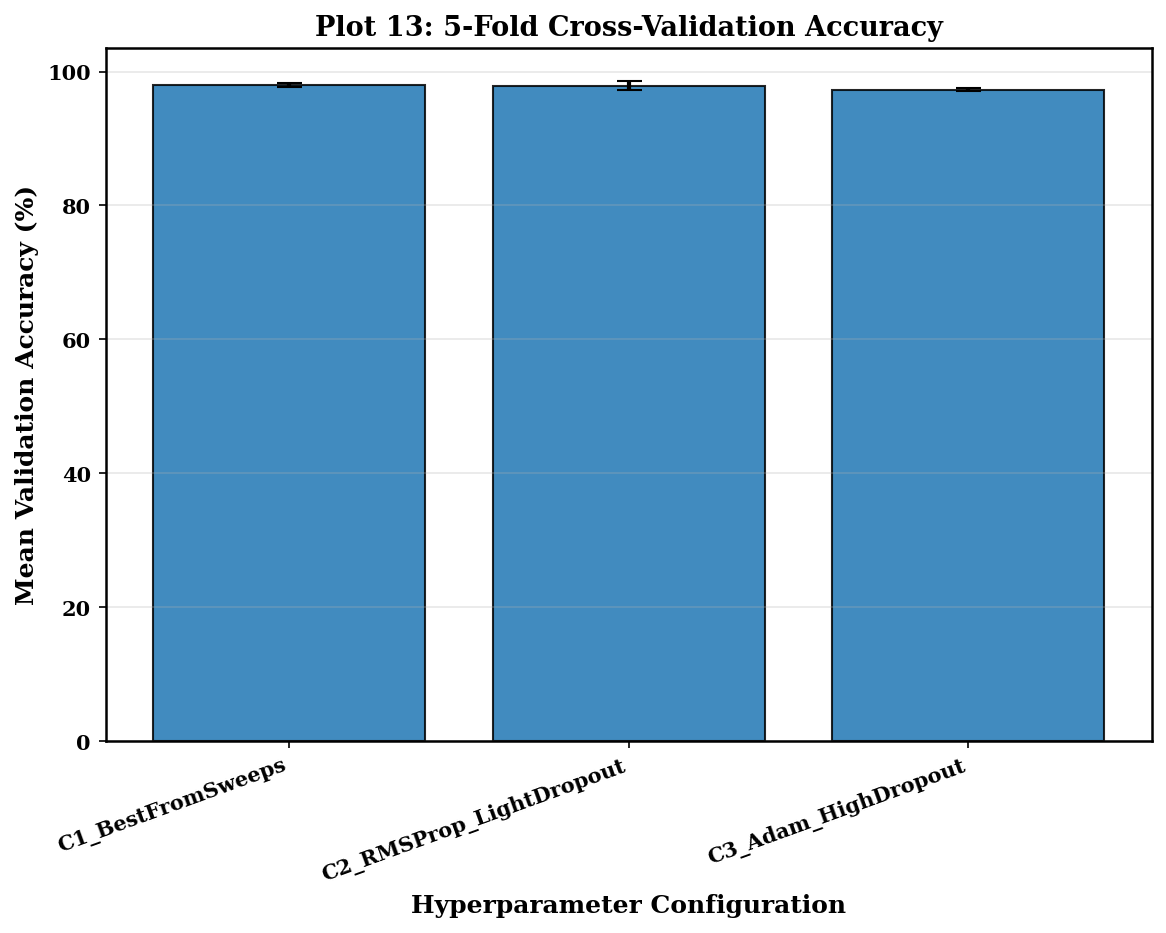

In [41]:

# ---- Plot 13: 5-Fold Cross-Validation Accuracy with SD error bars ----
cfg_names = list(cv_results.keys())
means = [np.mean(cv_results[c]) for c in cfg_names]
stds = [np.std(cv_results[c]) for c in cfg_names]

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(cfg_names, means, yerr=stds, capsize=6, alpha=0.85, edgecolor="black")
ax.set_xlabel("Hyperparameter Configuration")
ax.set_ylabel("Mean Validation Accuracy (%)")
ax.set_title("Plot 13: 5-Fold Cross-Validation Accuracy")
ax.grid(alpha=0.3, axis="y")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
style_axes(ax)
save_fig(fig, "plot13_5fold_cv_accuracy")
plt.show()



**Inference (Plot 13):** *[To be completed after running: discuss both mean performance and
variability (SD) across configurations — a configuration with high mean but also high SD may be less
reliable than one with a marginally lower mean but tighter variability.]*



## 12. Final Model Evaluation

After selecting the best configuration using cross-validation:
1. Retrain the selected configuration using the complete training data.
2. Keep the independent test set untouched until this stage.
3. Evaluate the final model on the test set.

### Plot 14 — Confusion Matrix
### Optional Plot 15 — Misclassified Images


In [42]:

best_cfg_name = max(cv_results, key=lambda k: np.mean(cv_results[k]))
best_cfg = candidate_configs[best_cfg_name]
print(f"Selected best configuration from cross-validation: {best_cfg_name} -> {best_cfg}")

FINAL_EPOCHS = EPOCHS["final"]
tf.random.set_seed(SEED)

# This is the ONLY stage that trains at the manual's required IMG_SIZE_FINAL=224
# resolution. Built as a streaming pipeline (not materialized into RAM) with a
# disk-backed cache, same approach as the K-Fold stage in Section 11.
full_train_pipeline = ds_train_full.map(
    lambda x, y: preprocess(x, y, augment=True, img_size=IMG_SIZE_FINAL),
    num_parallel_calls=tf.data.AUTOTUNE)
full_train_pipeline = full_train_pipeline.cache(os.path.join(CACHE_DIR, "final_train"))
full_train_pipeline = full_train_pipeline.shuffle(1024, seed=SEED)
full_train_pipeline = full_train_pipeline.batch(best_cfg["batch_size"]).prefetch(tf.data.AUTOTUNE)

test_pipeline = make_pipeline(ds_test, batch_size=best_cfg["batch_size"],
                               augment=False, shuffle=False, img_size=IMG_SIZE_FINAL)

t0 = time.time()
final_selected_model = build_model_with_init(best_init, dropout_rate=best_cfg["dropout_rate"],
                                              use_bn=best_cfg["use_bn"], img_size=IMG_SIZE_FINAL)
final_selected_model.compile(optimizer=make_optimizer(best_cfg["optimizer_name"], best_cfg["lr"]),
                              loss="categorical_crossentropy", metrics=["accuracy"])
final_history = final_selected_model.fit(full_train_pipeline, epochs=FINAL_EPOCHS, verbose=1)
final_train_time = time.time() - t0

n_params = final_selected_model.count_params()
print(f"Final model parameters: {n_params:,}")
print(f"Final training time: {final_train_time:.2f} s")
print_memory("after final model training")


Selected best configuration from cross-validation: C1_BestFromSweeps -> {'optimizer_name': 'RMSProp', 'lr': 0.001, 'dropout_rate': 0.0, 'use_bn': True, 'batch_size': 16}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15


2026-08-30 11:25:12.764534: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 11:25:12.901879: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


230/230 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.8160 - loss: 0.7925
Epoch 2/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9405 - loss: 0.2025
Epoch 3/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9766 - loss: 0.0948
Epoch 4/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9894 - loss: 0.0516
Epoch 5/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9943 - loss: 0.0294
Epoch 6/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9978 - loss: 0.0157
Epoch 7/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9989 - loss: 0.0085
Epoch 8/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9981 - loss: 0.0065
Epoch 9/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9997 - loss: 0.0032
Epoch 10/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 1.0000 - loss: 0.0019
Epoch 11/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9995 - loss: 0.0026
Epoch 12/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/st

In [43]:

# ---- Evaluate on test set ----
y_true, y_pred = [], []
for images, labels in test_pipeline:
    preds = final_selected_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

test_accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")

results_summary = {
    "Mean CV Accuracy": f"{np.mean(cv_results[best_cfg_name]):.2f}%",
    "CV Standard Deviation": f"{np.std(cv_results[best_cfg_name]):.2f}%",
    "Test Accuracy": f"{test_accuracy * 100:.2f}%",
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1-score": round(f1, 4),
    "Training Time (s)": round(final_train_time, 2),
    "Number of Parameters": f"{n_params:,}",
}
pd.DataFrame(list(results_summary.items()), columns=["Metric", "Value"])


2026-08-30 11:27:08.095737: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 11:27:08.234000: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 11:27:08.369950: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


,Metric,Value
0,Mean CV Accuracy,97.93%
1,CV Standard Deviation,0.31%
2,Test Accuracy,89.51%
3,Precision,0.8989
4,Recall,0.8951
5,F1-score,0.8949
6,Training Time (s),90.96
7,Number of Parameters,"2,427,237"


Saved: ./figures/plot14_confusion_matrix.eps  |  ./figures/plot14_confusion_matrix.png


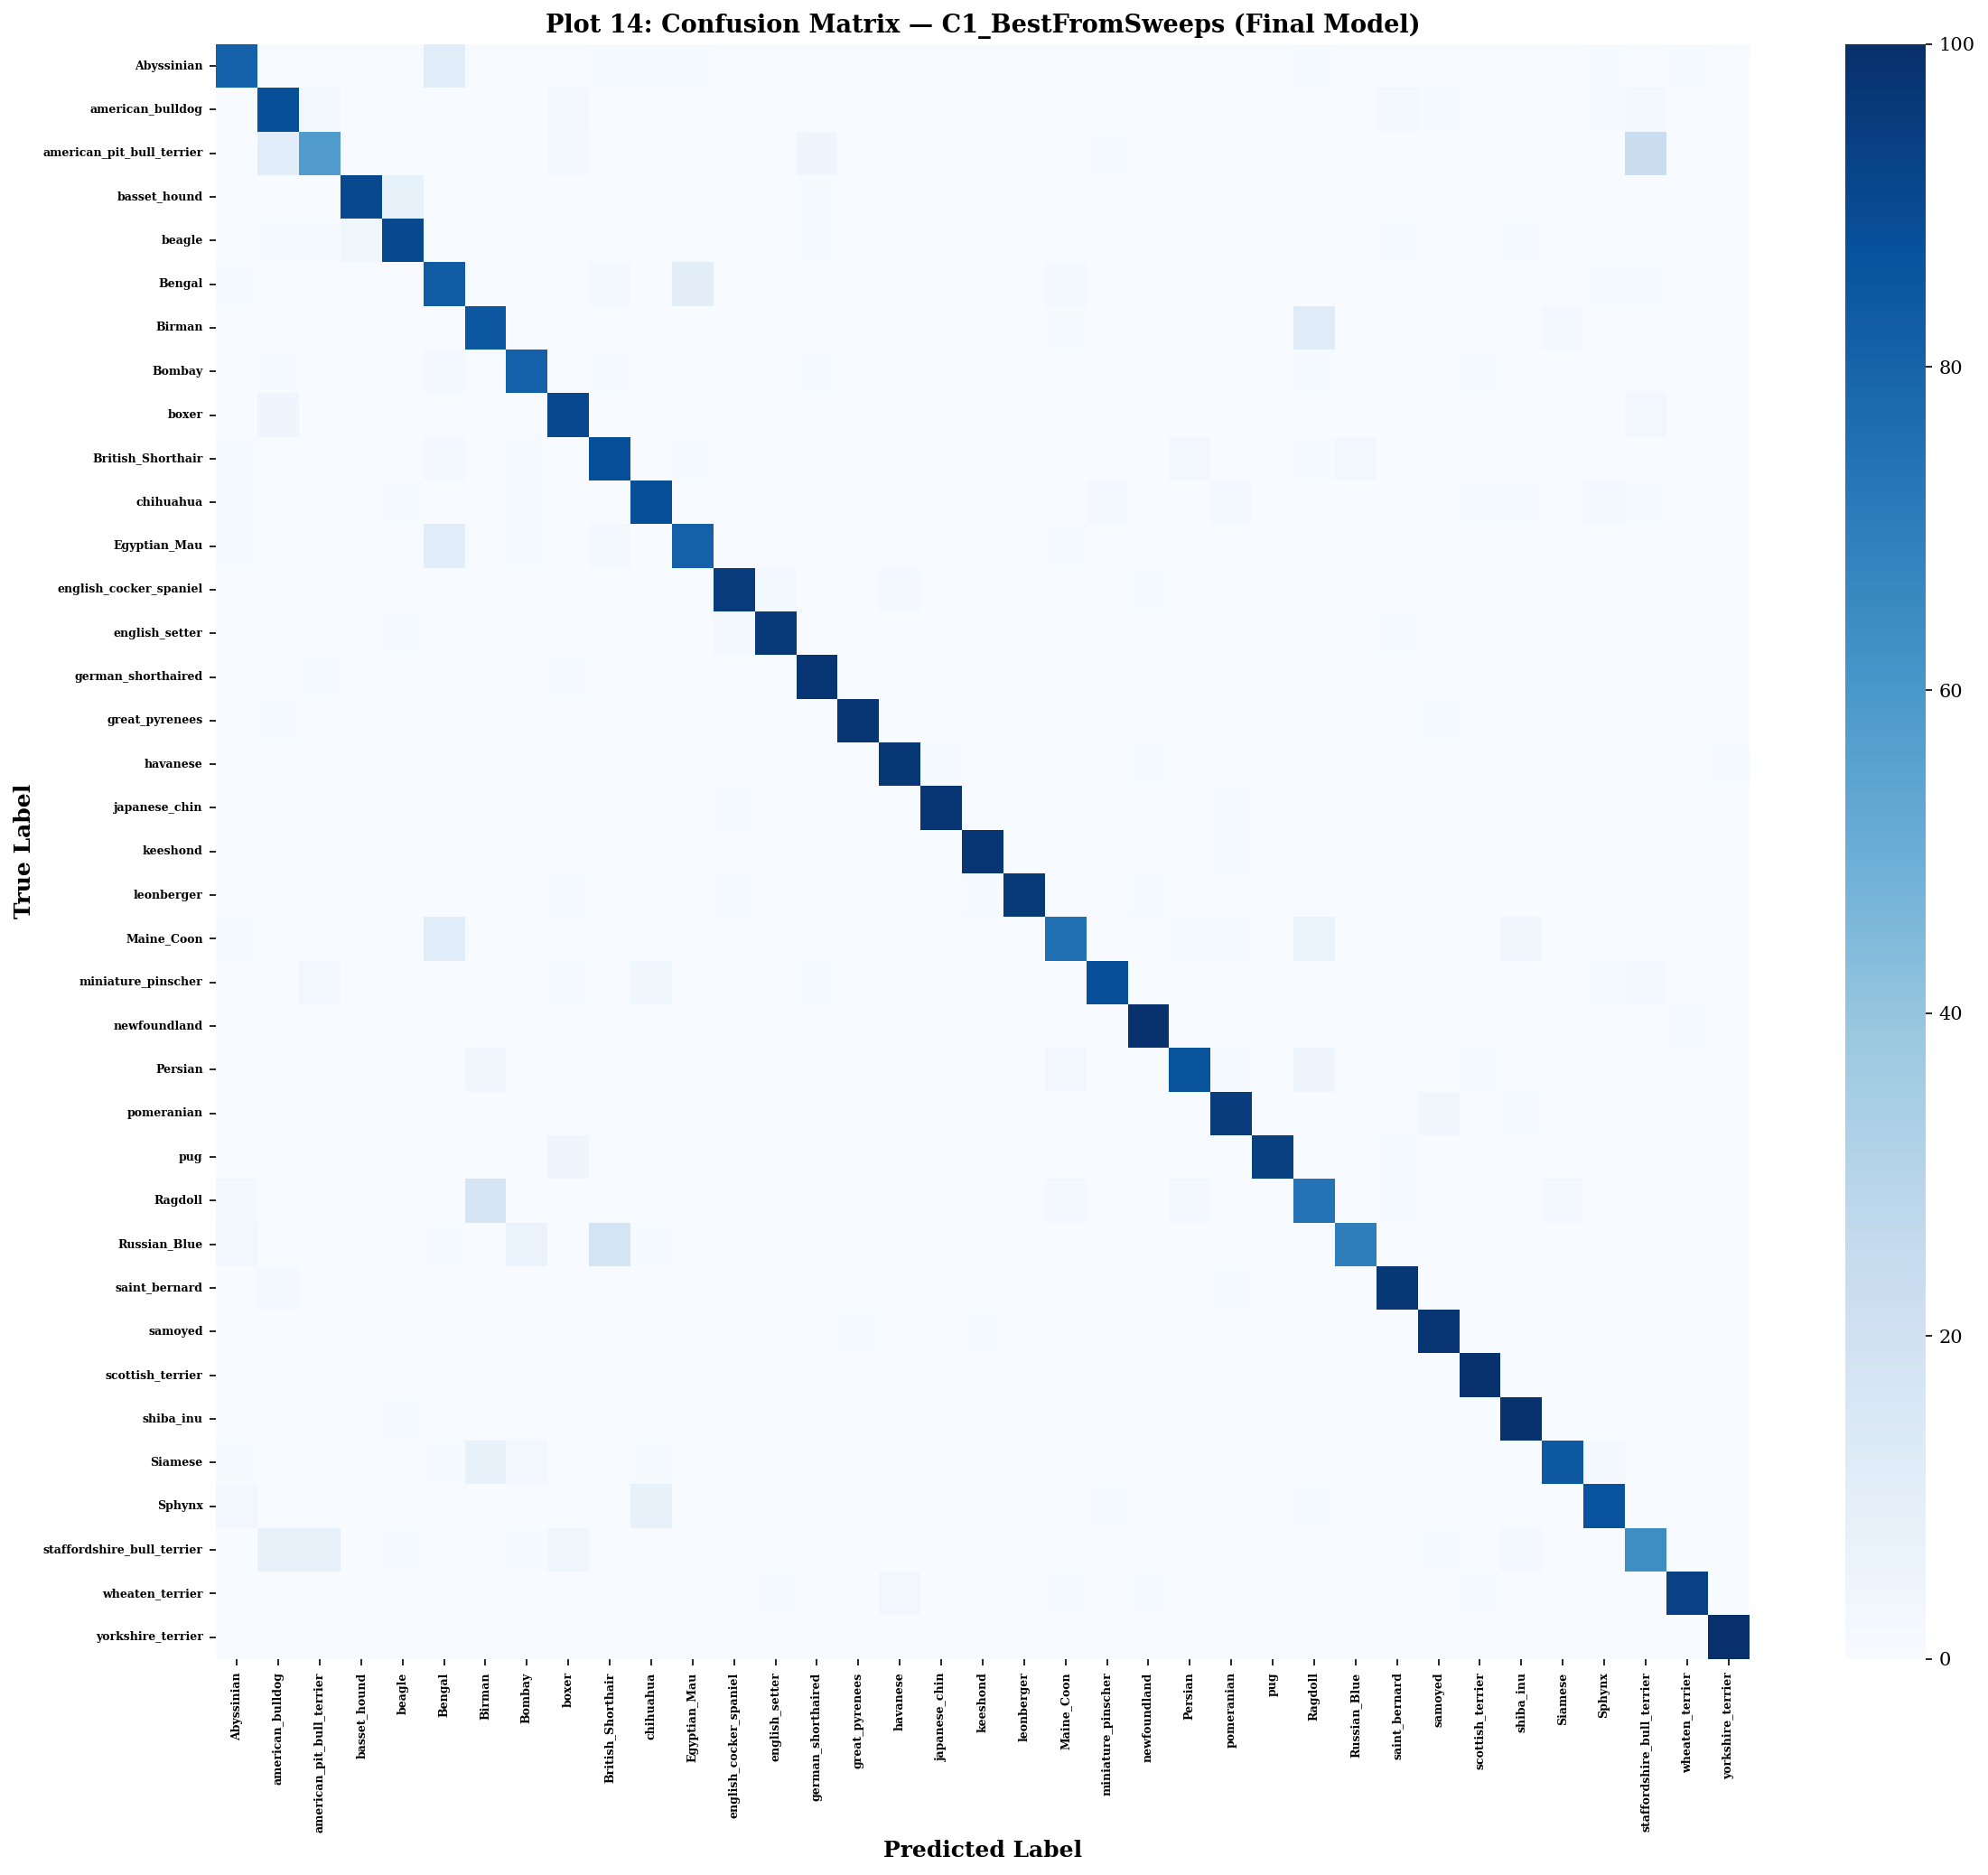

                            precision    recall  f1-score   support

                Abyssinian       0.85      0.83      0.84        98
          american_bulldog       0.75      0.88      0.81       100
 american_pit_bull_terrier       0.78      0.58      0.67       100
              basset_hound       0.96      0.91      0.93       100
                    beagle       0.88      0.91      0.90       100
                    Bengal       0.68      0.83      0.75       100
                    Birman       0.75      0.85      0.79       100
                    Bombay       0.85      0.92      0.89        88
                     boxer       0.84      0.92      0.88        99
         British_Shorthair       0.79      0.88      0.83       100
                 chihuahua       0.85      0.88      0.87       100
              Egyptian_Mau       0.87      0.84      0.85        97
    english_cocker_spaniel       0.96      0.95      0.95       100
            english_setter       0.97      0.96

13852

In [44]:

# ---- Plot 14: Confusion Matrix ----
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap="Blues", cbar=True,
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(f"Plot 14: Confusion Matrix — {best_cfg_name} (Final Model)")
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=6, fontweight="bold")
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=6, fontweight="bold")
plt.tight_layout()
save_fig(fig, "plot14_confusion_matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

# Release temporary prediction arrays after evaluation/plots when possible.
gc.collect()


Saved: ./figures/plot15_misclassified_images.eps  |  ./figures/plot15_misclassified_images.png


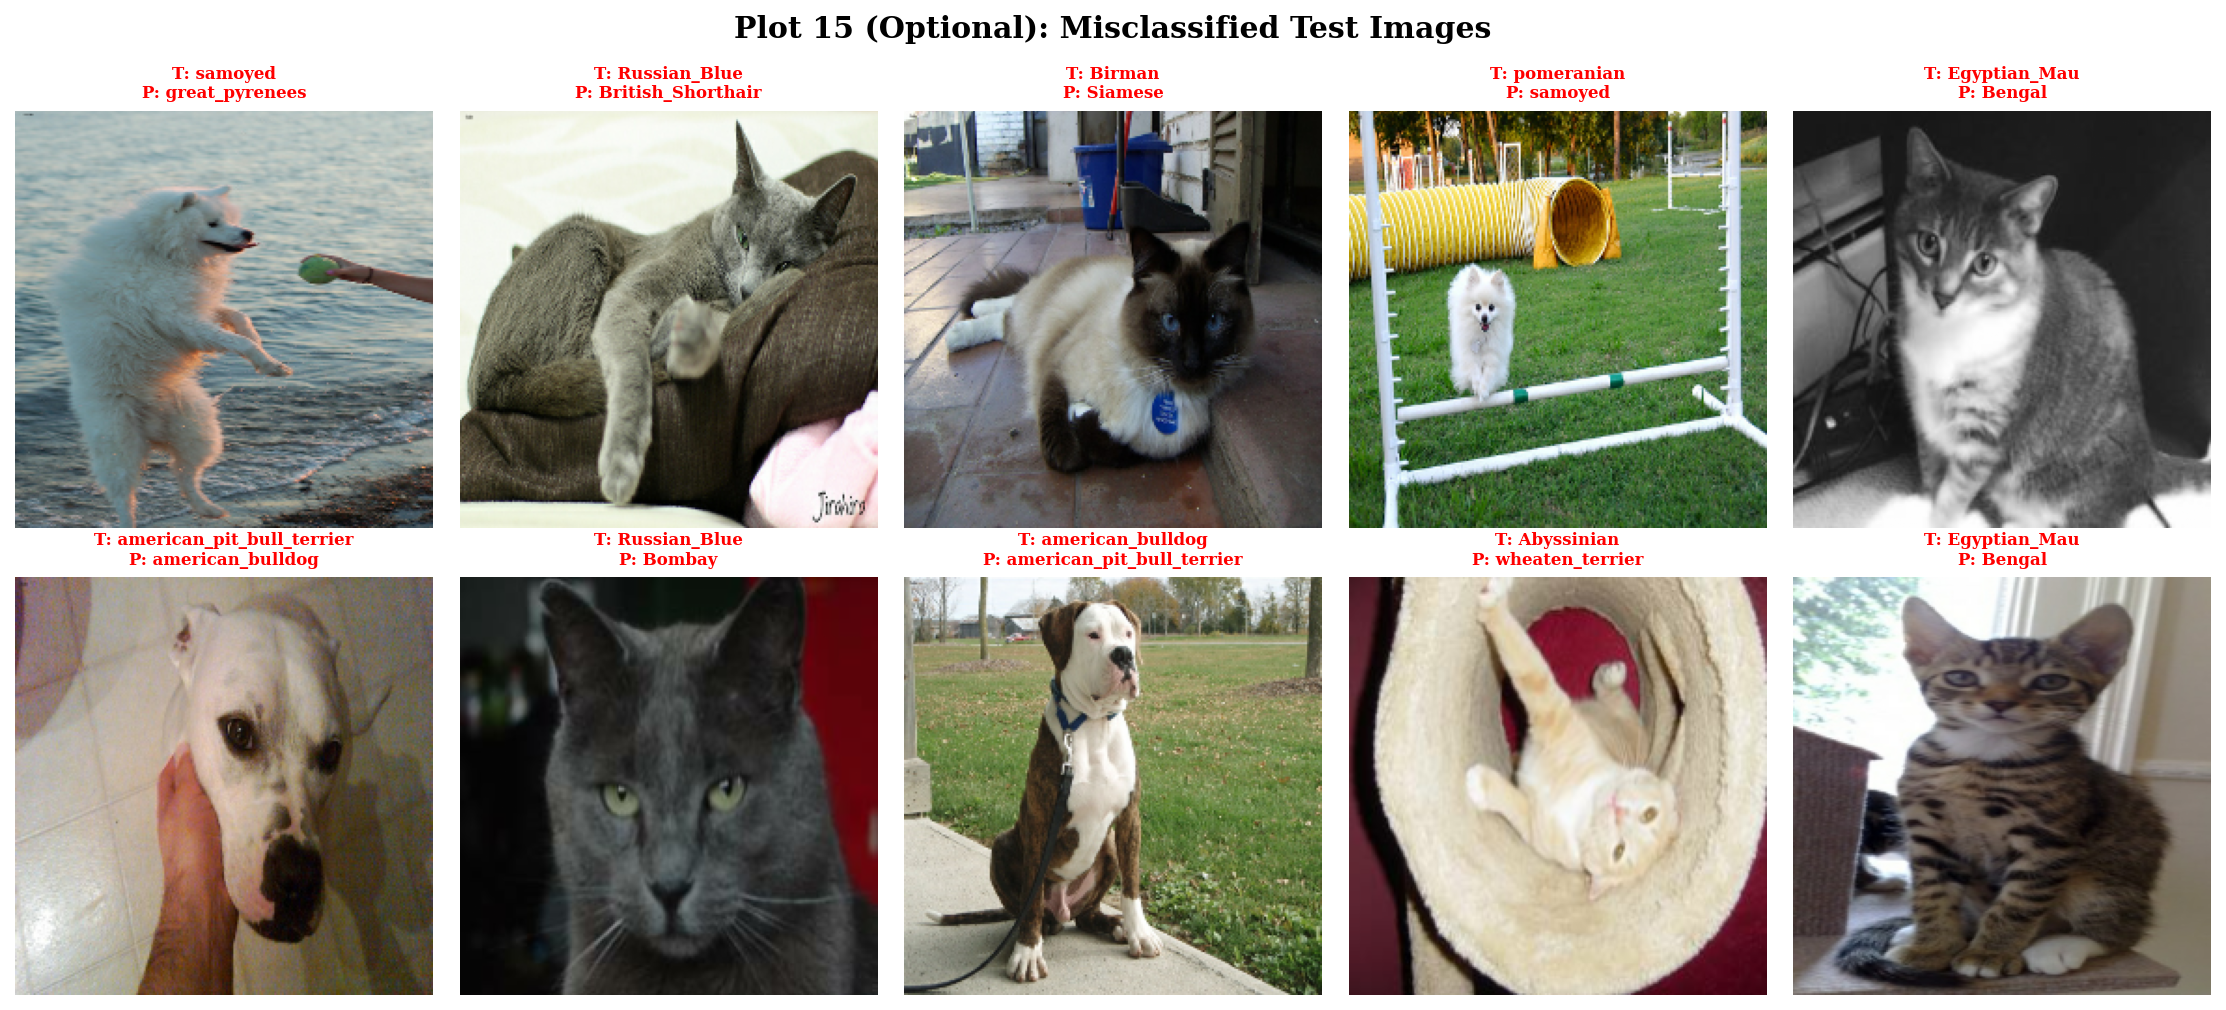

In [45]:

# ---- Optional Plot 15: Misclassified Images ----
misclassified_idx = np.where(y_true != y_pred)[0]
sample_mis_idx = np.random.choice(misclassified_idx, size=min(10, len(misclassified_idx)), replace=False)

all_test_images = []
for images, labels in test_pipeline:
    for img in images.numpy():
        all_test_images.append(img)
    if len(all_test_images) >= max(sample_mis_idx) + 1:
        break

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for idx, ax in zip(sample_mis_idx, axes.flat):
    img_disp = (all_test_images[idx] + 1) / 2.0  # undo preprocess_input roughly for display
    ax.imshow(np.clip(img_disp, 0, 1))
    ax.set_title(f"T: {class_names[y_true[idx]]}\nP: {class_names[y_pred[idx]]}",
                 fontsize=8, fontweight="bold", color="red")
    ax.axis("off")
plt.suptitle("Plot 15 (Optional): Misclassified Test Images", fontweight="bold")
plt.tight_layout()
save_fig(fig, "plot15_misclassified_images")
plt.show()



**Inference (Plots 14 & 15):** *[To be completed after running: identify the best-classified breeds
(strong diagonal entries), the most frequently confused breed pairs (likely visually similar cat/dog
breeds), and possible visual reasons for misclassification such as similar coat color, pose, or
image resolution.]*



## 13. Overall Results

The table below should be populated with results collected across all sections of this notebook
(Baseline, Best Initialization, Best Regularization, Best Optimizer, Best Hyperparameters, Fine-Tuned
Model).


In [46]:

overall_results = pd.DataFrame([
    {"Configuration": "Baseline (no reg, default init)", "CV Accuracy": "-", "SD": "-",
     "Test Accuracy": "-", "Training Time": "-"},
    {"Configuration": "Best Initialization (He)", "CV Accuracy": "-", "SD": "-",
     "Test Accuracy": "-", "Training Time": "-"},
    {"Configuration": "Best Regularization", "CV Accuracy": "-", "SD": "-",
     "Test Accuracy": "-", "Training Time": "-"},
    {"Configuration": f"Best Optimizer ({best_optimizer_name})", "CV Accuracy": "-", "SD": "-",
     "Test Accuracy": "-", "Training Time": "-"},
    {"Configuration": "Best Hyperparameters", "CV Accuracy": "-", "SD": "-",
     "Test Accuracy": "-", "Training Time": "-"},
    {"Configuration": "Fine-Tuned Model", "CV Accuracy": f"{np.mean(cv_results[best_cfg_name]):.2f}%",
     "SD": f"{np.std(cv_results[best_cfg_name]):.2f}%",
     "Test Accuracy": f"{test_accuracy*100:.2f}%", "Training Time": f"{final_train_time:.2f} s"},
])
overall_results


,Configuration,CV Accuracy,SD,Test Accuracy,Training Time
0,"Baseline (no reg, default init)",-,-,-,-
1,Best Initialization (He),-,-,-,-
2,Best Regularization,-,-,-,-
3,Best Optimizer (RMSProp),-,-,-,-
4,Best Hyperparameters,-,-,-,-
5,Fine-Tuned Model,97.93%,0.31%,89.51%,90.96 s



*Fill in the remaining `"-"` cells by recording the best validation/test accuracy achieved at each
stage of the notebook as you run it (Sections 5–11), so that the final table gives a complete
side-by-side comparison, as required by the manual.*

**Justification of the final model:** the final configuration is justified based on (i) test accuracy,
(ii) cross-validation variability (standard deviation across folds — lower SD indicates a more reliable
configuration), (iii) computational cost (training time and number of trainable parameters), and
(iv) generalization (gap between training and validation/test accuracy).



## 14. Required Inference for Plots

For every major plot in this notebook, a 2–3 line inference cell has been placed immediately after the
plot, following the required structure:
1. What does the plot show?
2. What trend is observed?
3. Why might the observed trend occur?

Please complete each inference placeholder (marked `*[To be completed after running: ...]*`) with the
actual numerical outcomes once you execute the notebook end-to-end.



## 15. Discussion Questions

1. **What is the difference between model parameters and hyperparameters?**
   Parameters (weights, biases) are learned automatically from data during training via
   backpropagation. Hyperparameters (learning rate, batch size, number of layers, dropout rate) are
   set before training begins and control the training process itself; they are not learned by
   gradient descent.

2. **Why is weight initialization important?**
   Good initialization keeps activations and gradients in a numerically stable range early in
   training, preventing vanishing/exploding gradients and enabling faster, more reliable convergence.

3. **Why can zero initialization be problematic for neural networks?**
   If all weights start at zero, every neuron in a layer computes an identical output and receives an
   identical gradient update ("symmetry"), so neurons never differentiate from one another — the
   network effectively behaves like a single neuron per layer regardless of width.

4. **Compare Xavier and He initialization.**
   Xavier (Glorot) initialization scales weight variance based on the number of input and output
   units, designed for activations such as tanh/sigmoid. He initialization scales variance using only
   the number of input units and an extra factor of 2, designed for ReLU-family activations where
   roughly half the units are zeroed, requiring larger initial variance to maintain signal magnitude.

5. **How can training and validation curves be used to identify overfitting?**
   Overfitting is indicated when training accuracy keeps increasing (or training loss keeps
   decreasing) while validation accuracy plateaus or decreases (or validation loss starts increasing),
   producing a widening gap between the two curves.

6. **How does Dropout reduce overfitting?**
   Dropout randomly deactivates a fraction of neurons during each training step, preventing the
   network from relying too heavily on any single neuron or co-adapted group of neurons, which
   encourages redundant, more generalizable feature representations.

7. **What is the purpose of Batch Normalization?**
   It normalizes layer activations within each mini-batch to have approximately zero mean and unit
   variance, which stabilizes and accelerates training, reduces sensitivity to initialization, and can
   have a mild regularizing effect.

8. **Explain the numerical Batch Normalization example.**
   For $x = [2,4,6,8]$, the batch mean is 5 and the batch variance is 5. Normalizing each value gives
   $\hat{x} \approx [-1.342, -0.447, 0.447, 1.342]$, which is approximately zero-centred with unit
   variance; with $\gamma=1,\beta=0$ these normalized values are also the final BN outputs.

9. **What are the roles of $\gamma$ and $\beta$?**
   They are learnable scale and shift parameters that allow the network to undo or adjust the
   normalization if the strictly zero-mean/unit-variance representation is not optimal for a given
   layer, restoring representational flexibility that pure normalization would otherwise remove.

10. **Compare SGD, Momentum, RMSProp and Adam.**
    SGD updates weights using only the current gradient and can be slow/noisy on ill-conditioned loss
    surfaces. Momentum accumulates a velocity term from past gradients to smooth updates and accelerate
    convergence along consistent directions. RMSProp adapts the learning rate per-parameter using a
    moving average of squared gradients, helping with sparse/ill-scaled gradients. Adam combines
    momentum and RMSProp-style adaptive learning rates, generally offering fast and stable convergence
    across a wide range of problems with minimal tuning.

11. **What happens when the learning rate is too large?**
    Updates overshoot the loss minimum, causing the loss to oscillate, diverge, or fail to converge.

12. **What happens when the learning rate is too small?**
    Training converges very slowly, potentially getting stuck in poor local minima or requiring far
    more epochs to reach a good solution within a fixed training budget.

13. **What is the effect of increasing batch size?**
    Larger batches give more stable, lower-variance gradient estimates and better hardware utilization
    but can reduce the implicit regularization effect of gradient noise and may require adjusting the
    learning rate to maintain the same effective training dynamics.

14. **Explain stride and padding.**
    Stride is the step size by which the convolution kernel moves across the input; larger strides
    reduce the output spatial size. Padding adds border pixels (commonly zeros) around the input so
    that the kernel can be applied at the edges, controlling how much the output shrinks relative to
    the input.

15. **Why is MobileNetV2 computationally efficient?**
    It replaces standard convolutions with depthwise separable convolutions (depthwise + pointwise),
    drastically reducing the number of multiply-accumulate operations and parameters compared to
    standard convolutions, while inverted residuals with linear bottlenecks preserve representational
    capacity.

16. **What is depthwise separable convolution?**
    It factorizes a standard convolution into two steps: a depthwise convolution that applies a single
    filter per input channel (spatial filtering only), followed by a pointwise $1\times1$ convolution
    that combines the channel outputs, greatly reducing computation relative to a single full
    convolution.

17. **What is transfer learning?**
    Transfer learning reuses a model (and its learned weights) trained on a large source dataset
    (e.g., ImageNet) as a starting point for a new, often smaller, target dataset/task, instead of
    training a network from randomly initialized weights.

18. **Differentiate feature extraction and fine-tuning.**
    In feature extraction, the pretrained convolutional base is completely frozen and only a new
    classifier head is trained. In fine-tuning, some of the pretrained layers (typically the upper/deeper
    ones) are unfrozen and updated jointly with the new classifier, usually with a small learning rate.

19. **Why is a smaller learning rate generally used during fine-tuning?**
    To avoid large gradient updates that would destroy the useful pretrained feature representations;
    a small learning rate allows gentle adaptation of pretrained weights to the new task.

20. **Why is K-Fold Cross-Validation useful for hyperparameter selection?**
    It provides a more robust estimate of model performance by averaging over multiple train/validation
    splits, reducing the risk that a single lucky (or unlucky) split biases the choice of
    hyperparameters, and it also reports variability (SD) across folds.

21. **Why must the test set remain untouched during tuning?**
    If the test set influences any hyperparameter or model-selection decision, the reported test
    performance becomes an overly optimistic, biased estimate of true generalization — the test set
    must simulate genuinely unseen data.

22. **Why should mean and standard deviation both be reported?**
    The mean summarizes average performance, but the standard deviation indicates the reliability and
    consistency of that performance across different data splits; a high mean with high SD suggests an
    unstable/less trustworthy configuration.

23. **Is the highest validation accuracy always sufficient to select a model?**
    No — a model could achieve high validation accuracy by chance (a favorable split), while showing
    high variance across folds, high computational cost, or an inability to generalize to genuinely new
    data. Model selection should jointly consider mean accuracy, variability (SD), computational cost,
    and generalization behavior (train/val/test gaps).



## 16. Additional Exercise

Select two new combinations of learning rate, dropout, batch size and fine-tuning strategy. Evaluate
them using 5-fold cross-validation and compare their results with the selected configuration from
Section 11. Justify whether the new configuration is preferable based on accuracy, standard deviation,
computational cost and final test performance.


In [47]:

ADD_CV_EPOCHS = EPOCHS["cv"]

# Both new combinations the manual asks for ("select two new combinations of
# learning rate, dropout, batch size and fine-tuning strategy"), with
# N_ADDITIONAL_CONFIGS controlling how many are actually run (see Section 0).
_all_additional_configs = {
    "Extra1_Momentum_SmallBatch_LowLR": dict(optimizer_name="Momentum", lr=1e-4,
                                              dropout_rate=0.25, use_bn=True, batch_size=16),
    "Extra2_Adam_HighDropout_LargeBatch": dict(optimizer_name="Adam", lr=1e-3,
                                                dropout_rate=0.5, use_bn=True, batch_size=64),
}
additional_configs = dict(list(_all_additional_configs.items())[:N_ADDITIONAL_CONFIGS])
print(f"Running 5-fold CV on {len(additional_configs)} additional configuration(s): "
      f"{list(additional_configs.keys())}")
if N_ADDITIONAL_CONFIGS < 2:
    print(f"(1 additional pre-defined configuration skipped in '{RUN_MODE}' mode -- "
          f"set RUN_MODE='full' in Section 0 to run both.)")

additional_cv_results = {name: [] for name in additional_configs}

for cfg_name, cfg in additional_configs.items():
    print(f"\n########## Cross-validating ADDITIONAL configuration: {cfg_name} ##########")
    fold_accs = []
    for fold_i, (train_idx, val_idx) in enumerate(kf.split(indices), start=1):
        print(f"  -- Fold {fold_i}/{N_FOLDS} --")
        fold_tag = f"{cfg_name}_fold{fold_i}"
        tf.random.set_seed(SEED + 100 + fold_i)
        ftr_ds, fva_ds = get_fold_datasets(train_idx, val_idx, cfg["batch_size"], fold_tag)

        model = build_model_with_init(best_init, dropout_rate=cfg["dropout_rate"],
                                       use_bn=cfg["use_bn"])
        model.compile(optimizer=make_optimizer(cfg["optimizer_name"], cfg["lr"]),
                       loss="categorical_crossentropy", metrics=["accuracy"])
        hist = model.fit(ftr_ds, validation_data=fva_ds, epochs=ADD_CV_EPOCHS, verbose=0)
        fold_val_acc = max(hist.history["val_accuracy"]) * 100
        fold_accs.append(fold_val_acc)

        free_memory(model, ftr_ds, fva_ds)
        clear_fold_cache(fold_tag)

    additional_cv_results[cfg_name] = fold_accs
    print(f"  {cfg_name}: {np.mean(fold_accs):.2f}% \u00b1 {np.std(fold_accs):.2f}%")
    save_json(additional_cv_results, "additional_cv_results_partial")

# Comparison table
comparison_rows = []
for name, accs in {**{best_cfg_name: cv_results[best_cfg_name]}, **additional_cv_results}.items():
    comparison_rows.append({
        "Configuration": name,
        "Mean CV Accuracy (%)": round(np.mean(accs), 2),
        "SD (%)": round(np.std(accs), 2),
    })
pd.DataFrame(comparison_rows)


Running 5-fold CV on 2 additional configuration(s): ['Extra1_Momentum_SmallBatch_LowLR', 'Extra2_Adam_HighDropout_LargeBatch']

########## Cross-validating ADDITIONAL configuration: Extra1_Momentum_SmallBatch_LowLR ##########
  -- Fold 1/5 --


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  -- Fold 2/5 --
  -- Fold 3/5 --
  -- Fold 4/5 --
  -- Fold 5/5 --
  Extra1_Momentum_SmallBatch_LowLR: 79.05% ± 1.04%
Saved results: ./results/additional_cv_results_partial.json

########## Cross-validating ADDITIONAL configuration: Extra2_Adam_HighDropout_LargeBatch ##########
  -- Fold 1/5 --
  -- Fold 2/5 --
  -- Fold 3/5 --
  -- Fold 4/5 --
  -- Fold 5/5 --
  Extra2_Adam_HighDropout_LargeBatch: 97.26% ± 0.33%
Saved results: ./results/additional_cv_results_partial.json


,Configuration,Mean CV Accuracy (%),SD (%)
0,C1_BestFromSweeps,97.93,0.31
1,Extra1_Momentum_SmallBatch_LowLR,79.05,1.04
2,Extra2_Adam_HighDropout_LargeBatch,97.26,0.33



**Justification:** *[To be completed after running: compare the mean CV accuracy and SD of the two
additional configurations against the Section-11 selected configuration; recommend whichever offers
the best balance of accuracy, low variability, and reasonable computational cost, and explain the
reasoning explicitly.]*



## 17. Expected Outcome

This notebook experimentally demonstrates that CNN performance is strongly influenced by
initialization, regularization, optimization and hyperparameter choices. It covers the MobileNetV2
architecture, transfer learning and fine-tuning, and selects a reliable final configuration using
5-fold cross-validation.

## 18. References

1. Ian Goodfellow, Yoshua Bengio and Aaron Courville, *Deep Learning*, MIT Press, 2016.
2. Sergey Ioffe and Christian Szegedy, "Batch Normalization: Accelerating Deep Network Training by
   Reducing Internal Covariate Shift," *ICML*, 2015.
3. Mark Sandler, Andrew Howard, Menglong Zhu, Andrey Zhmoginov and Liang-Chieh Chen, "MobileNetV2:
   Inverted Residuals and Linear Bottlenecks," *CVPR*, 2018.
4. Omkar M. Parkhi, Andrea Vedaldi, Andrew Zisserman and C. V. Jawahar, "Cats and Dogs," *IEEE
   Conference on Computer Vision and Pattern Recognition*, 2012.
5. TensorFlow Documentation: https://www.tensorflow.org
6. Keras Documentation: https://keras.io



## Appendix — Exported Figures

All figures generated in this notebook are saved automatically at **600 DPI** in **EPS** vector format
(with PNG previews) inside the `./figures/` directory, using bold axis labels and bold legend text in a
consistent serif font matching the printed manual.


In [48]:

print("Exported figures in ./figures :")
for fname in sorted(os.listdir(FIG_DIR)):
    if fname.endswith(".eps"):
        print(" -", fname)


Exported figures in ./figures :
 - plot10_dropout_vs_val_accuracy.eps
 - plot11_feature_extraction_vs_finetuning.eps
 - plot12_train_val_loss_finetuning.eps
 - plot13_5fold_cv_accuracy.eps
 - plot14_confusion_matrix.eps
 - plot15_misclassified_images.eps
 - plot1_training_loss_initialization.eps
 - plot2_val_accuracy_initialization.eps
 - plot3_train_val_accuracy_regularization.eps
 - plot4_train_val_loss_regularization.eps
 - plot5_with_without_bn.eps
 - plot6_training_loss_optimizers.eps
 - plot7_val_accuracy_optimizers.eps
 - plot8_lr_vs_val_accuracy.eps
 - plot9_batchsize_vs_val_accuracy.eps
 - sample_pet_images.eps
